# FID and Memorization Evaluation

Compare trained checkpoints with FID and nearest-neighbor memorization metrics.


In [1]:
from google.colab import drive
drive.mount("/content/drive")


Mounted at /content/drive


## Raw FID Evaluation


In [4]:
# Single Colab cell: raw-model FID against training data and test data only.

import os
import sys
import math
import copy
import gc
import subprocess
from types import SimpleNamespace

import numpy as np
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms

from torch.utils.data import Subset, DataLoader
from tqdm.auto import tqdm

# Settings

PROJECT_PATH = "/content/drive/MyDrive/DD2424/Project/working_nets"

FID_NUM_GENERATED = 1000
FID_GEN_BATCH_SIZE = 500
FID_REAL_MAX_IMAGES = 1000

SAMPLE_NUM_STEPS = 1000
SAMPLE_EPS = 1e-3
SAMPLE_SNR = 0.01
RANDOM_SEED = 0

BATCH_SIZE = 128
FID_FEATURE = 2048
SHOW_SAMPLING_PROGRESS = True

# Set to None to run every raw model listed below.
MODEL_NAMES_TO_RUN = None

# Raw weights only. No EMA weights are loaded.
MODEL_SPECS = [
    {
        "name": "bird_ve_ncsnpp_non_augmented_raw_1760",
        "checkpoint": "bird_ncsnpp_ve_ema_checkpoint_epoch_1760.pth",
        "dataset": "cifar10_bird",
        "model_type": "ve_ncsnpp_fourier",
        "sde": "ve",
        "image_size": 32,
        "raw_keys": ["ncsnpp", "ve_net"],
        "corrector_steps": 0,
    },
    {
        "name": "bird_ve_ncsnpp_augmented_raw_1760",
        "checkpoint": "bird_ve_sde_augmented_final_ncsnpp_1760_epochs.pth",
        "dataset": "cifar10_bird",
        "model_type": "ve_ncsnpp_original",
        "sde": "ve",
        "image_size": 32,
        "raw_keys": ["ve_net", "ncsnpp"],
        "corrector_steps": 0,
        "ve_prior_scale": 1.0,
    },
    {
        "name": "bird_vp_ddpmpp_augmented_raw_1760",
        "checkpoint": "bird_vp_sde_augmented_final_ddpmpp_1760_epochs.pth",
        "dataset": "cifar10_bird",
        "model_type": "vp_ddpmpp",
        "sde": "vp",
        "image_size": 32,
        "raw_keys": ["vp_net"],
        "corrector_steps": 0,
    },
    {
        "name": "bird_vp_ddpmpp_non_augmented_raw_1760",
        "checkpoint": "bird_vp_sde_non_augmented_final_ddpmpp_1760_epochs.pth",
        "dataset": "cifar10_bird",
        "model_type": "vp_ddpmpp",
        "sde": "vp",
        "image_size": 32,
        "raw_keys": ["vp_net"],
        "corrector_steps": 0,
    },
    {
        "name": "bird_vp_unet_augmented_raw_1760",
        "checkpoint": "bird_vp_sde_augmented_final_U_net_1760_epochs.pth",
        "dataset": "cifar10_bird",
        "model_type": "vp_unet",
        "sde": "vp",
        "image_size": 32,
        "raw_keys": ["vp_net"],
        "corrector_steps": 0,
    },
    {
        "name": "bird_vp_unet_non_augmented_raw_1760",
        "checkpoint": "bird_vp_sde_checkpoint_1760_epochs.pth",
        "dataset": "cifar10_bird",
        "model_type": "vp_unet",
        "sde": "vp",
        "image_size": 32,
        "raw_keys": ["vp_net"],
        "corrector_steps": 0,
    },
    {
        "name": "flower_vp_ddpmpp_augmented_raw_1760",
        "checkpoint": "flower_vp_sde_augmented_final_ddpmpp_1760_epochs.pth",
        "dataset": "flowers",
        "model_type": "vp_ddpmpp",
        "sde": "vp",
        "image_size": 48,
        "raw_keys": ["vp_net"],
        "corrector_steps": 0,
    },
    {
        "name": "flower_vp_ddpmpp_non_augmented_raw_1760",
        "checkpoint": "flower_vp_sde_non_augmented_final_ddpmpp_1760_epochs.pth",
        "dataset": "flowers",
        "model_type": "vp_ddpmpp",
        "sde": "vp",
        "image_size": 48,
        "raw_keys": ["vp_net"],
        "corrector_steps": 0,
    },
]

# Setup

subprocess.check_call([
    sys.executable, "-m", "pip", "install", "-q",
    "ninja", "ml-collections", "torchmetrics", "torch-fidelity"
])

try:
    from google.colab import drive
    try:
        drive.mount("/content/drive")
    except ValueError:
        pass
except Exception:
    pass

device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

torch.backends.cudnn.benchmark = True

if PROJECT_PATH not in sys.path:
    sys.path.insert(0, PROJECT_PATH)

score_sde_repository_path = os.path.join(PROJECT_PATH, "score_sde_pytorch")
if not os.path.exists(score_sde_repository_path):
    subprocess.check_call([
        "git", "clone",
        "https://github.com/yang-song/score_sde_pytorch.git",
        score_sde_repository_path
    ])

if score_sde_repository_path not in sys.path:
    sys.path.insert(0, score_sde_repository_path)

from models.ncsnpp import NCSNpp
from torchmetrics.image.fid import FrechetInceptionDistance

# Data

DATA_LOADER_CACHE = {}

def get_plain_data_loaders(dataset_name, image_size):
    cache_key = (dataset_name, image_size)
    if cache_key in DATA_LOADER_CACHE:
        return DATA_LOADER_CACHE[cache_key]

    pin_memory=torch.cuda.is_available()

    if dataset_name == "cifar10_bird":
        transform_plain = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.5, 0.5, 0.5),
                                 (0.5, 0.5, 0.5))
        ])

        train_full = torchvision.datasets.CIFAR10(root="./data", train=True, download=True, transform=transform_plain)

        target_idx = train_full.classes.index("bird")
        train_indices = [
            i for i, label in enumerate(train_full.targets)
            if label == target_idx
        ]
        trainset = Subset(train_full, train_indices)

        test_full = torchvision.datasets.CIFAR10(root="./data", train=False, download=True, transform=transform_plain)

        test_indices = [
            i for i, label in enumerate(test_full.targets)
            if label == target_idx
        ]
        testset = Subset(test_full, test_indices)

    elif dataset_name == "flowers":
        transform_plain = transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.ToTensor(),
            transforms.Normalize((0.5, 0.5, 0.5),
                                 (0.5, 0.5, 0.5))
        ])

        trainset = torchvision.datasets.Flowers102(root="./data", split="train", download=True, transform=transform_plain)

        testset = torchvision.datasets.Flowers102(root="./data", split="test", download=True, transform=transform_plain)

    else:
        raise ValueError(f"Unknown dataset: {dataset_name}")

    trainloader = DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=pin_memory)

    testloader = DataLoader(testset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=pin_memory)

    loaders = {
        "train": trainloader,
        "test": testloader,
        "num_train": len(trainset),
        "num_test": len(testset),
    }

    DATA_LOADER_CACHE[cache_key] = loaders

    print(f"Dataset: {dataset_name}")
    print("Training images:", len(trainset))
    print("Test images:", len(testset))

    return loaders

# U-Net raw VP model

class SinusoidalTimeEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim=dim

    def forward(self, t):
        half = self.dim // 2
        emb = math.log(10000) / (half - 1)
        emb = torch.exp(torch.arange(half, device=t.device) * -emb)
        emb = t[:, None] * emb[None, :]
        emb = torch.cat([torch.sin(emb), torch.cos(emb)], dim=1)
        return emb


class SelfAttention(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.norm = nn.GroupNorm(32, ch)
        self.q = nn.Conv2d(ch, ch, 1)
        self.k = nn.Conv2d(ch, ch, 1)
        self.v = nn.Conv2d(ch, ch, 1)
        self.proj = nn.Conv2d(ch, ch, 1)

    def forward(self, x):
        B, C, H, W = x.shape
        h = self.norm(x)

        q = self.q(h).reshape(B, C, H * W).permute(0, 2, 1)
        k = self.k(h).reshape(B, C, H * W)
        v = self.v(h).reshape(B, C, H * W)

        attn = torch.softmax(q @ k / math.sqrt(C), dim=-1)
        out = (v @ attn.permute(0, 2, 1)).reshape(B, C, H, W)

        return x + self.proj(out)


class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, emb_dim):
        super().__init__()

        self.norm1 = nn.GroupNorm(32, in_ch)
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)

        self.norm2 = nn.GroupNorm(32, out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)

        self.emb_proj = nn.Linear(emb_dim, out_ch * 2)
        self.act = nn.SiLU()
        self.skip = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x, emb):
        h = self.conv1(self.act(self.norm1(x)))

        scale, shift = self.emb_proj(emb).chunk(2, dim=1)
        scale = scale[:, :, None, None]
        shift = shift[:, :, None, None]

        h = self.norm2(h)
        h = h * (1 + scale) + shift
        h = self.conv2(self.act(h))

        return h + self.skip(x)


class Downsample(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.conv = nn.Conv2d(ch, ch, 4, 2, 1)

    def forward(self, x):
        return self.conv(x)


class Upsample(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.conv = nn.ConvTranspose2d(ch, ch, 4, 2, 1)

    def forward(self, x):
        return self.conv(x)


class UNet(nn.Module):
    def __init__(self, img_ch=3, base_ch=128):
        super().__init__()

        emb_dim = base_ch * 4

        self.time_emb = SinusoidalTimeEmbedding(emb_dim)
        self.emb_mlp = nn.Sequential(
            nn.Linear(emb_dim, emb_dim),
            nn.SiLU(),
            nn.Linear(emb_dim, emb_dim)
        )

        self.conv_in = nn.Conv2d(img_ch, base_ch, 3, padding=1)

        self.down1 = ResBlock(base_ch, 128, emb_dim)
        self.ds0 = Downsample(128)

        self.down2 = ResBlock(128, 256, emb_dim)
        self.ds1 = Downsample(256)

        self.down3 = ResBlock(256, 512, emb_dim)
        self.attn16 = SelfAttention(512)
        self.ds2 = Downsample(512)

        self.down4 = ResBlock(512, 512, emb_dim)
        self.attn8 = SelfAttention(512)

        self.mid1 = ResBlock(512, 512, emb_dim)
        self.mid_attn = SelfAttention(512)
        self.mid2 = ResBlock(512, 512, emb_dim)

        self.up4 = ResBlock(1024, 512, emb_dim)
        self.attn8_up = SelfAttention(512)
        self.us2 = Upsample(512)

        self.up3 = ResBlock(1024, 512, emb_dim)
        self.attn16_up = SelfAttention(512)
        self.us1 = Upsample(512)

        self.up2 = ResBlock(768, 256, emb_dim)
        self.us0 = Upsample(256)

        self.up1 = ResBlock(384, 128, emb_dim)

        self.conv_out = nn.Conv2d(128, img_ch, 3, padding=1)

    def forward(self, x, t):
        emb = self.emb_mlp(self.time_emb(t * 999.0))

        x = self.conv_in(x)

        d1 = self.down1(x, emb)
        d1_down = self.ds0(d1)

        d2 = self.down2(d1_down, emb)
        d2_down = self.ds1(d2)

        d3 = self.down3(d2_down, emb)
        d3 = self.attn16(d3)
        d3_down = self.ds2(d3)

        d4 = self.down4(d3_down, emb)
        d4 = self.attn8(d4)

        mid = self.mid1(d4, emb)
        mid = self.mid_attn(mid)
        mid = self.mid2(mid, emb)

        u4 = self.up4(torch.cat([mid, d4], dim=1), emb)
        u4 = self.attn8_up(u4)
        u4_up = self.us2(u4)

        u3 = self.up3(torch.cat([u4_up, d3], dim=1), emb)
        u3 = self.attn16_up(u3)
        u3_up = self.us1(u3)

        u2 = self.up2(torch.cat([u3_up, d2], dim=1), emb)
        u2_up = self.us0(u2)

        u1 = self.up1(torch.cat([u2_up, d1], dim=1), emb)

        return self.conv_out(u1)

# NCSN++ / DDPM++ configs

def create_ddpmpp_vp_config(image_size=32, image_channels=3):
    config = SimpleNamespace()

    config.training = SimpleNamespace()
    config.training.continuous = True

    config.data = SimpleNamespace()
    config.data.image_size = image_size
    config.data.num_channels = image_channels
    config.data.centered = True

    config.model=SimpleNamespace()
    config.model.name = "ncsnpp"
    config.model.sigma_min = 0.01
    config.model.sigma_max = 50
    config.model.num_scales = 1000
    config.model.beta_min = 0.1
    config.model.beta_max = 20.0
    config.model.nf = 64
    config.model.ch_mult = (1, 2, 2, 2)
    config.model.num_res_blocks = 2
    config.model.attn_resolutions = (16,)
    config.model.dropout = 0.1
    config.model.scale_by_sigma = False
    config.model.normalization = "GroupNorm"
    config.model.nonlinearity = "swish"
    config.model.resamp_with_conv = True
    config.model.conditional = True
    config.model.fir = True
    config.model.fir_kernel = [1, 3, 3, 1]
    config.model.skip_rescale = True
    config.model.resblock_type = "biggan"
    config.model.progressive = "none"
    config.model.progressive_input = "residual"
    config.model.progressive_combine = "sum"
    config.model.attention_type = "ddpm"
    config.model.init_scale = 0.0
    config.model.embedding_type = "positional"
    config.model.fourier_scale = 16
    config.model.conv_size = 3

    return config


def create_ncsnpp_ve_config(image_size=32, image_channels=3):
    config = SimpleNamespace()

    config.data = SimpleNamespace()
    config.data.image_size = image_size
    config.data.num_channels = image_channels
    config.data.centered = True

    config.training = SimpleNamespace()
    config.training.sde = "vesde"
    config.training.continuous = True

    config.model=SimpleNamespace()
    config.model.name = "ncsnpp"
    config.model.sigma_min = 0.01
    config.model.sigma_max = 50.0
    config.model.num_scales = 1000
    config.model.scale_by_sigma = True
    config.model.ema_rate = 0.999
    config.model.normalization = "GroupNorm"
    config.model.nonlinearity = "swish"
    config.model.nf = 128
    config.model.ch_mult = (1, 2, 2, 2)
    config.model.num_res_blocks = 4
    config.model.attn_resolutions = (16,)
    config.model.dropout = 0.1
    config.model.resamp_with_conv = True
    config.model.conditional = True
    config.model.fir = True
    config.model.fir_kernel = [1, 3, 3, 1]
    config.model.skip_rescale = True
    config.model.resblock_type = "biggan"
    config.model.progressive = "none"
    config.model.progressive_input = "residual"
    config.model.progressive_combine = "sum"
    config.model.attention_type = "ddpm"
    config.model.init_scale = 0.0
    config.model.embedding_type = "fourier"
    config.model.fourier_scale = 16
    config.model.conv_size = 3

    return config

# SDE wrappers and samplers

def vp_perturbation_kernel(t, x0, beta_min=0.1, beta_max=20.0):
    integral_beta = beta_min * t + 0.5 * (beta_max - beta_min) * t ** 2
    mean = torch.exp(-0.5 * integral_beta).view(-1, 1, 1, 1) * x0
    std = torch.sqrt(1.0 - torch.exp(-integral_beta)).view(-1, 1, 1, 1)
    return mean, std


def beta_t(t, beta_min=0.1, beta_max=20.0):
    return beta_min + t * (beta_max - beta_min)


def ve_sigma_t(t, sigma_min=0.01, sigma_max=50.0):
    return sigma_min * (sigma_max / sigma_min) ** t


class NCSNppVPScoreWrapper(nn.Module):
    def __init__(self, official_model, number_of_scales=1000, beta_min=0.1, beta_max=20.0):
        super().__init__()
        self.official_model = official_model
        self.number_of_scales = number_of_scales
        self.beta_min = beta_min
        self.beta_max = beta_max

    def forward(self, images, continuous_timesteps):
        timestep_labels = continuous_timesteps * (self.number_of_scales - 1)
        model_output = self.official_model(images, timestep_labels)
        _, std = vp_perturbation_kernel(continuous_timesteps, images, beta_min=self.beta_min, beta_max=self.beta_max)
        return -model_output / std


class NCSNppVEFourierScoreWrapper(nn.Module):
    def __init__(self, official_model, sigma_min=0.01, sigma_max=50.0):
        super().__init__()
        self.official_model = official_model
        self.sigma_min = sigma_min
        self.sigma_max = sigma_max

    def forward(self, images, continuous_timesteps):
        sigmas = ve_sigma_t(continuous_timesteps, sigma_min=self.sigma_min, sigma_max=self.sigma_max)
        return self.official_model(images, sigmas)


class NCSNppVEOriginalScoreWrapper(nn.Module):
    def __init__(self, official_model, number_of_scales=1000, sigma_min=0.01, sigma_max=50.0):
        super().__init__()
        self.official_model = official_model
        self.number_of_scales = number_of_scales
        self.sigma_min = sigma_min
        self.sigma_max = sigma_max

    def forward(self, images, continuous_timesteps):
        timestep_labels = continuous_timesteps * (self.number_of_scales - 1)
        model_output = self.official_model(images, timestep_labels)
        std = ve_sigma_t(continuous_timesteps, sigma_min=self.sigma_min, sigma_max=self.sigma_max).view(-1, 1, 1, 1)
        return -model_output / std


@torch.no_grad()
def langevin_corrector_vp(x, t, net, snr=0.01, n_steps=0, eps=1e-12):
    B = x.shape[0]
    batch_t = torch.ones(B, device=x.device) * t

    for _ in range(n_steps):
        score = net(x, batch_t)
        noise = torch.randn_like(x)

        score_norm = torch.norm(score.reshape(B, -1), dim=1).mean()
        noise_norm = torch.norm(noise.reshape(B, -1), dim=1).mean()

        step_size = 2.0 * (snr * noise_norm / (score_norm + eps)) ** 2
        x_mean = x + step_size * score
        x = x_mean + torch.sqrt(2.0 * step_size) * noise

    return x, x_mean


@torch.no_grad()
def euler_maruyama_predictor_vp(x, t, t_next, net, beta_min=0.1, beta_max=20.0, add_noise=True):
    B = x.shape[0]
    h = t - t_next
    batch_t = torch.ones(B, device=x.device) * t

    beta = beta_t(batch_t, beta_min=beta_min, beta_max=beta_max).view(-1, 1, 1, 1)
    score = net(x, batch_t)

    drift = 0.5 * beta * x + beta * score
    x_mean = x + drift * h

    if add_noise:
        noise = torch.randn_like(x)
        x = x_mean + torch.sqrt(beta * h) * noise
    else:
        x = x_mean

    return x, x_mean


@torch.no_grad()
def sample_vp_sde(net, num_samples, img_shape, num_steps, eps, snr, corrector_steps, beta_min, beta_max, denoise=True):
    net.eval()

    x = torch.randn(num_samples, *img_shape, device=device)
    timesteps = torch.linspace(1.0, eps, num_steps, device=device)

    x_mean = x

    iterator = tqdm(range(num_steps - 1), desc="VP sampling", leave=False, disable=not SHOW_SAMPLING_PROGRESS)

    for i in iterator:
        t = timesteps[i]
        t_next = timesteps[i + 1]

        if corrector_steps > 0:
            x, x_mean = langevin_corrector_vp(x=x, t=t, net=net, snr=snr, n_steps=corrector_steps)

        add_noise = i < num_steps - 2

        x, x_mean = euler_maruyama_predictor_vp(x=x, t=t, t_next=t_next, net=net, beta_min=beta_min, beta_max=beta_max, add_noise=add_noise)

    return (x_mean if denoise else x).clamp(-1, 1)


@torch.no_grad()
def langevin_corrector_ve(x, t, net, snr=0.01, n_steps=1, eps=1e-12):
    B = x.shape[0]
    batch_t = torch.ones(B, device=x.device) * t

    for _ in range(n_steps):
        noise = torch.randn_like(x)
        score = net(x, batch_t)

        score_norm = torch.norm(score.reshape(B, -1), dim=1).mean()
        noise_norm = torch.norm(noise.reshape(B, -1), dim=1).mean()

        step_size = 2.0 * (snr * noise_norm / (score_norm + eps)) ** 2
        x_mean = x + step_size * score
        x = x_mean + torch.sqrt(2.0 * step_size) * noise

    return x, x_mean


def ve_g_squared_t(batch_t, sigma_min=0.01, sigma_max=50.0):
    sig_t = ve_sigma_t(batch_t, sigma_min=sigma_min, sigma_max=sigma_max)
    return 2.0 * (sig_t ** 2) * math.log(sigma_max / sigma_min)


@torch.no_grad()
def euler_maruyama_predictor_ve(x, t, t_next, net, sigma_min=0.01, sigma_max=50.0, add_noise=True):
    B = x.shape[0]
    h = t - t_next
    batch_t = torch.ones(B, device=x.device) * t

    g_squared = ve_g_squared_t(batch_t, sigma_min=sigma_min, sigma_max=sigma_max).view(-1, 1, 1, 1)

    score = net(x, batch_t)
    drift = g_squared * score

    x_mean = x + drift * h

    if add_noise:
        noise = torch.randn_like(x)
        x = x_mean + torch.sqrt(g_squared * h) * noise
    else:
        x = x_mean

    return x, x_mean


@torch.no_grad()
def sample_ve_sde(net, num_samples, img_shape, num_steps, eps, snr, corrector_steps, sigma_min, sigma_max, prior_scale=None, denoise=True):
    net.eval()

    if prior_scale is None:
        prior_scale = sigma_max

    x = torch.randn(num_samples, *img_shape, device=device) * prior_scale
    timesteps = torch.linspace(1.0, eps, num_steps, device=device)

    x_mean = x

    iterator = tqdm(range(num_steps - 1), desc="VE sampling", leave=False, disable=not SHOW_SAMPLING_PROGRESS)

    for i in iterator:
        t = timesteps[i]
        t_next = timesteps[i + 1]

        if corrector_steps > 0:
            x, x_mean = langevin_corrector_ve(x=x, t=t, net=net, snr=snr, n_steps=corrector_steps)

        add_noise = i < num_steps - 2

        x, x_mean = euler_maruyama_predictor_ve(x=x, t=t, t_next=t_next, net=net, sigma_min=sigma_min, sigma_max=sigma_max, add_noise=add_noise)

    return (x_mean if denoise else x).clamp(-1, 1)

# Loading raw models

def checkpoint_get(checkpoint, key, default):
    if isinstance(checkpoint, dict):
        return checkpoint.get(key, default)
    return default


def torch_load_checkpoint(checkpoint_path):
    try:
        return torch.load(checkpoint_path, map_location="cpu", weights_only=False)
    except TypeError:
        return torch.load(checkpoint_path, map_location="cpu")


def select_raw_state_dict(checkpoint, raw_keys):
    if isinstance(checkpoint, dict):
        for key in raw_keys:
            if key in checkpoint:
                return checkpoint[key]

        if all(torch.is_tensor(v) for v in checkpoint.values()):
            return checkpoint

    raise KeyError(f"Could not find raw weights. Tried keys: {raw_keys}")


def strip_prefix_if_present(state_dict, prefix):
    keys = list(state_dict.keys())
    if len(keys) > 0 and all(k.startswith(prefix) for k in keys):
        return {k[len(prefix):]: v for k, v in state_dict.items()}
    return state_dict


def clean_state_dict(state_dict):
    state_dict = strip_prefix_if_present(state_dict, "module.")
    state_dict = strip_prefix_if_present(state_dict, "_orig_mod.")
    return state_dict


def load_raw_state(model, state_dict):
    state_dict = clean_state_dict(state_dict)

    try:
        model.load_state_dict(state_dict, strict=True)
        return
    except RuntimeError as first_error:
        if hasattr(model, "official_model"):
            official_state = {
                k.replace("official_model.", "", 1) if k.startswith("official_model.") else k: v
                for k, v in state_dict.items()
            }
            try:
                model.official_model.load_state_dict(clean_state_dict(official_state), strict=True)
                return
            except RuntimeError:
                pass

        raise first_error


def build_model(spec, checkpoint):
    image_size = spec["image_size"]
    model_type = spec["model_type"]

    beta_min = float(checkpoint_get(checkpoint, "bar_b_min", 0.1))
    beta_max = float(checkpoint_get(checkpoint, "bar_b_max", 20.0))
    sigma_min = float(checkpoint_get(checkpoint, "bar_sigma_min", 0.01))
    sigma_max = float(checkpoint_get(checkpoint, "bar_sigma_max", 50.0))

    meta = {
        "sde": spec["sde"],
        "image_shape": (3, image_size, image_size),
        "beta_min": beta_min,
        "beta_max": beta_max,
        "sigma_min": sigma_min,
        "sigma_max": sigma_max,
        "prior_scale": spec.get("ve_prior_scale", None),
    }

    if model_type == "vp_unet":
        model=UNet().to(device)

    elif model_type == "vp_ddpmpp":
        config = create_ddpmpp_vp_config(image_size=image_size, image_channels=3)
        official_model = NCSNpp(config).to(device)
        model=NCSNppVPScoreWrapper(official_model=official_model, number_of_scales=config.model.num_scales, beta_min=beta_min, beta_max=beta_max).to(device)

    elif model_type == "ve_ncsnpp_fourier":
        config = create_ncsnpp_ve_config(image_size=image_size, image_channels=3)
        official_model = NCSNpp(config).to(device)
        model=NCSNppVEFourierScoreWrapper(official_model=official_model, sigma_min=sigma_min, sigma_max=sigma_max).to(device)

    elif model_type == "ve_ncsnpp_original":
        config = create_ncsnpp_ve_config(image_size=image_size, image_channels=3)
        official_model = NCSNpp(config).to(device)
        model=NCSNppVEOriginalScoreWrapper(official_model=official_model, number_of_scales=config.model.num_scales, sigma_min=sigma_min, sigma_max=sigma_max).to(device)

    else:
        raise ValueError(f"Unknown model_type: {model_type}")

    model.eval()
    for p in model.parameters():
        p.requires_grad_(False)

    return model, meta

# FID

def denormalize(x):
    return (x / 2 + 0.5).clamp(0, 1)


def to_uint8_images(x):
    x = denormalize(x)
    x = (x * 255.0).round().clamp(0, 255).to(torch.uint8)
    return x


@torch.no_grad()
def generate_raw_samples(model, spec, meta):
    torch.manual_seed(RANDOM_SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(RANDOM_SEED)

    all_samples = []
    generated = 0

    while generated < FID_NUM_GENERATED:
        current_batch = min(FID_GEN_BATCH_SIZE, FID_NUM_GENERATED - generated)

        if meta["sde"] == "vp":
            samples = sample_vp_sde(net=model, num_samples=current_batch, img_shape=meta["image_shape"],
                num_steps=SAMPLE_NUM_STEPS, eps=SAMPLE_EPS, snr=SAMPLE_SNR, corrector_steps=spec["corrector_steps"],
                beta_min=meta["beta_min"], beta_max=meta["beta_max"], denoise=True)

        elif meta["sde"] == "ve":
            samples = sample_ve_sde(net=model, num_samples=current_batch, img_shape=meta["image_shape"],
                num_steps=SAMPLE_NUM_STEPS, eps=SAMPLE_EPS, snr=SAMPLE_SNR, corrector_steps=spec["corrector_steps"],
                sigma_min=meta["sigma_min"], sigma_max=meta["sigma_max"], prior_scale=meta["prior_scale"], denoise=True)

        else:
            raise ValueError(f"Unknown SDE: {meta['sde']}")

        all_samples.append(samples.detach().cpu())
        generated += current_batch

        print(f"Generated raw samples: {generated}/{FID_NUM_GENERATED}")

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    return torch.cat(all_samples, dim=0)


@torch.no_grad()
def compute_fid_from_generated(generated_samples, real_loader, real_name):
    fid = FrechetInceptionDistance(
        feature=FID_FEATURE,
        normalize=False
    ).to(device)

    real_count = 0

    for real_images, _ in real_loader:
        if FID_REAL_MAX_IMAGES is not None:
            remaining = FID_REAL_MAX_IMAGES - real_count
            if remaining <= 0:
                break
            real_images = real_images[:remaining]

        real_images = real_images.to(device)
        fid.update(to_uint8_images(real_images), real=True)

        real_count += real_images.shape[0]

        if FID_REAL_MAX_IMAGES is not None and real_count >= FID_REAL_MAX_IMAGES:
            break

    print(f"Real {real_name} images added to FID:", real_count)

    gen_count = 0

    for start in range(0, generated_samples.shape[0], FID_GEN_BATCH_SIZE):
        end = min(start + FID_GEN_BATCH_SIZE, generated_samples.shape[0])
        gen_batch = generated_samples[start:end].to(device)

        fid.update(to_uint8_images(gen_batch), real=False)

        gen_count += gen_batch.shape[0]
        print(f"Generated images added to {real_name} FID: {gen_count}/{generated_samples.shape[0]}")

    fid_value = fid.compute().item()

    del fid
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return fid_value, real_count

# Run

def evaluate_one_raw_model(spec):
    checkpoint_path = os.path.join(PROJECT_PATH, spec["checkpoint"])

    if not os.path.exists(checkpoint_path):
        print("\nSkipping missing checkpoint:", checkpoint_path)
        return None

    print("\n====================================")
    print("Raw model:", spec["name"])
    print("Checkpoint:", checkpoint_path)
    print("====================================")

    checkpoint = torch_load_checkpoint(checkpoint_path)

    model, meta = build_model(spec, checkpoint)
    raw_state = select_raw_state_dict(checkpoint, spec["raw_keys"])
    load_raw_state(model, raw_state)

    del raw_state
    gc.collect()

    generated_samples = generate_raw_samples(model, spec, meta)

    model.to("cpu")
    del model
    del checkpoint
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    loaders = get_plain_data_loaders(spec["dataset"], spec["image_size"])

    fid_train, train_real_count = compute_fid_from_generated(generated_samples=generated_samples, real_loader=loaders["train"], real_name="training")

    fid_test, test_real_count = compute_fid_from_generated(generated_samples=generated_samples, real_loader=loaders["test"], real_name="test")

    difference = fid_test - fid_train

    result = {
        "model_name": spec["name"],
        "checkpoint": checkpoint_path,
        "fid_train": fid_train,
        "fid_test": fid_test,
        "fid_test_minus_train": difference,
        "fid_abs_difference": abs(difference),
        "train_real_images_used": train_real_count,
        "test_real_images_used": test_real_count,
        "generated_images_used": generated_samples.shape[0],
    }

    print("\nFID results:")
    print(f"model_name: {result['model_name']}")
    print(f"fid_train: {result['fid_train']:.6f}")
    print(f"fid_test: {result['fid_test']:.6f}")
    print(f"fid_test_minus_train: {result['fid_test_minus_train']:.6f}")
    print(f"fid_abs_difference: {result['fid_abs_difference']:.6f}")

    del generated_samples
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return result


selected_names = None if MODEL_NAMES_TO_RUN is None else set(MODEL_NAMES_TO_RUN)

all_results = []
if True:
  for spec in MODEL_SPECS:
      if selected_names is not None and spec["name"] not in selected_names:
          continue

      result = evaluate_one_raw_model(spec)

      if result is not None:
          all_results.append(result)

  print("\n====================================")
  print("Final raw-model FID summary")
  print("====================================")

  for result in all_results:
      print(
          f"{result['model_name']} | "
          f"FID train={result['fid_train']:.6f} | "
          f"FID test = {result['fid_test']:.6f} | "
          f"test - train={result['fid_test_minus_train']:.6f}"
      )

all_results


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using device: cuda

Raw model: bird_ve_ncsnpp_non_augmented_raw_1760
Checkpoint: /content/drive/MyDrive/DD2424/Project/working_nets/bird_ncsnpp_ve_ema_checkpoint_epoch_1760.pth


VE sampling:   0%|          | 0/999 [00:00<?, ?it/s]

Generated raw samples: 500/5000


VE sampling:   0%|          | 0/999 [00:00<?, ?it/s]

Generated raw samples: 1000/5000


...

VP sampling:   0%|          | 0/999 [00:00<?, ?it/s]

Generated raw samples: 4500/5000


VP sampling:   0%|          | 0/999 [00:00<?, ?it/s]

Generated raw samples: 5000/5000
Real training images added to FID: 1020
Generated images added to training FID: 500/5000
Generated images added to training FID: 1000/5000
Generated images added to training FID: 1500/5000
Generated images added to training FID: 2000/5000
Generated images added to training FID: 2500/5000
Generated images added to training FID: 3000/5000
Generated images added to training FID: 3500/5000
Generated images added to training FID: 4000/5000
Generated images added to training FID: 4500/5000
Generated images added to training FID: 5000/5000
Real test images added to FID: 5000
Generated images added to test FID: 500/5000
Generated images added to test FID: 1000/5000
Generated images added to test FID: 1500/5000
Generated images added to test FID: 2000/5000
Generated images added to test FID: 2500/5000
Generated images added to test FID: 3000/5000
Generated images added to test FID: 3500/5000
Generated images added to test FID: 4000/5000
Generated images added to

[{'model_name': 'bird_ve_ncsnpp_non_augmented_raw_1760',
  'checkpoint': '/content/drive/MyDrive/DD2424/Project/working_nets/bird_ncsnpp_ve_ema_checkpoint_epoch_1760.pth',
  'fid_train': 32.07174301147461,
  'fid_test': 52.17082977294922,
  'fid_test_minus_train': 20.09908676147461,
  'fid_abs_difference': 20.09908676147461,
  'train_real_images_used': 5000,
  'test_real_images_used': 1000,
  'generated_images_used': 5000},
 {'model_name': 'bird_ve_ncsnpp_augmented_raw_1760',
  'checkpoint': '/content/drive/MyDrive/DD2424/Project/working_nets/bird_ve_sde_augmented_final_ncsnpp_1760_epochs.pth',
  'fid_train': 35.3807373046875,
  'fid_test': 57.868896484375,
  'fid_test_minus_train': 22.4881591796875,
  'fid_abs_difference': 22.4881591796875,
  'train_real_images_used': 5000,
  'test_real_images_used': 1000,
  'generated_images_used': 5000},
 {'model_name': 'bird_vp_ddpmpp_augmented_raw_1760',
  'checkpoint': '/content/drive/MyDrive/DD2424/Project/working_nets/bird_vp_sde_augmented_fina

| Dataset | SDE    | Architecture | Augmented | FID train<br>(5,000 images) | FID test<br>(1,000 images) | Test − train |
| ------- | ------ | ------------ | :-------: | --------------------------: | -------------------------: | -----------: |
| Bird    | VE-SDE | NCSN++       |     No    |                   32.071743 |                  52.170830 |    20.099087 |
| Bird    | VE-SDE | NCSN++       |    Yes    |                   35.380737 |                  57.868896 |    22.488159 |
| Bird    | VP-SDE | DDPM++       |    Yes    |                   40.423515 |                  61.931145 |    21.507629 |
| Bird    | VP-SDE | DDPM++       |     No    |                   31.792177 |                  51.868164 |    20.075987 |
| Bird    | VP-SDE | U-Net        |    Yes    |                   39.020283 |                  60.589489 |    21.569206 |
| Bird    | VP-SDE | U-Net        |     No    |                   29.418001 |                  49.855522 |    20.437521 |
| Flower  | VP-SDE | DDPM++       |    Yes    |                  114.030556 |                 103.367661 |   -10.662895 |
| Flower  | VP-SDE | DDPM++       |     No    |                   82.152328 |                  73.685799 |    -8.466530 |


## Previous Run Summary


| Model                            | Augmented | FID train | FID test | Δ FID test − train |
| -------------------------------- | :-------: | --------: | -------: | -----------------: |
| Bird VE-SDE NCSN++, Epoch 1760   |     No    |    63.654 |   62.949 |             -0.705 |
| Bird VE-SDE NCSN++, Epoch 1760   |    Yes    |    69.430 |   68.876 |             -0.554 |
| Bird VP-SDE DDPM++, Epoch 1760   |    Yes    |    73.205 |   73.846 |              0.641 |
| Bird VP-SDE DDPM++, Epoch 1760   |     No    |    62.638 |   63.175 |              0.537 |
| Bird VP-SDE U-Net, Epoch 1760    |    Yes    |    71.355 |   71.561 |              0.206 |
| Bird VP-SDE U-Net, Epoch 1760    |     No    |    57.910 |   59.301 |              1.391 |
| Flower VP-SDE DDPM++, Epoch 1760 |    Yes    |   122.153 |  128.439 |              6.286 |
| Flower VP-SDE DDPM++, Epoch 1760 |     No    |    88.813 |   96.011 |              7.198 |





## Raw Memorization Evaluation


In [5]:
# Separate Colab cell: raw-model memorization / overfitting analysis.
# Assumes the previous FID cell has already been run.


# Memorization settings

MEM_NUM_GENERATED = 1000          # Increase to 1000 for stronger statistics.
MEM_GEN_BATCH_SIZE = 64
MEM_NUM_STEPS = 1000
MEM_EPS = 1e-3
MEM_SNR = 0.01

# Collect a larger pool, then compare against equal-size random train/test subsets.
MEM_REFERENCE_POOL_IMAGES = 5000
MEM_REFERENCE_COMPARE_IMAGES = 1000

NN_GEN_BATCH_SIZE = 64
NN_REF_BATCH_SIZE = 512

MEM_RANDOM_SEED = 0
SAVE_MEM_RESULTS_CSV = True
MEM_RESULTS_CSV = os.path.join(PROJECT_PATH, "raw_memorization_analysis_results.csv")

# Set to None to run every raw model from MODEL_SPECS.
MODEL_NAMES_TO_RUN_MEM = None

COPY_MSE_THRESHOLDS = [1e-4, 1e-3, 1e-2]


# Checks

required_names = [
    "MODEL_SPECS",
    "PROJECT_PATH",
    "device",
    "torch_load_checkpoint",
    "build_model",
    "select_raw_state_dict",
    "load_raw_state",
    "get_plain_data_loaders",
    "sample_vp_sde",
    "sample_ve_sde",
]

missing = [name for name in required_names if name not in globals()]
if missing:
    raise RuntimeError(
        "Run the FID cell first. Missing definitions: " + ", ".join(missing)
    )


# Helpers

def count_parameters(model):
    return sum(p.numel() for p in model.parameters())


@torch.no_grad()
def collect_reference_images(loader, max_images):
    chunks = []
    count = 0

    for images, _ in loader:
        chunks.append(images.cpu())
        count += images.shape[0]

        if count >= max_images:
            break

    images = torch.cat(chunks, dim=0)
    return images[:max_images]


def random_subset_images(images, n, seed):
    n = min(n, images.shape[0])
    generator = torch.Generator()
    generator.manual_seed(seed)
    indices = torch.randperm(images.shape[0], generator=generator)[:n]
    return images[indices]


@torch.no_grad()
def generate_mem_samples(model, spec, meta):
    torch.manual_seed(MEM_RANDOM_SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(MEM_RANDOM_SEED)

    all_samples = []
    generated = 0

    while generated < MEM_NUM_GENERATED:
        current_batch = min(MEM_GEN_BATCH_SIZE, MEM_NUM_GENERATED - generated)

        if meta["sde"] == "vp":
            samples = sample_vp_sde(net=model, num_samples=current_batch, img_shape=meta["image_shape"],
                num_steps=MEM_NUM_STEPS, eps=MEM_EPS, snr=MEM_SNR, corrector_steps=spec["corrector_steps"],
                beta_min=meta["beta_min"], beta_max=meta["beta_max"], denoise=True)
        elif meta["sde"] == "ve":
            samples = sample_ve_sde(net=model, num_samples=current_batch, img_shape=meta["image_shape"],
                num_steps=MEM_NUM_STEPS, eps=MEM_EPS, snr=MEM_SNR, corrector_steps=spec["corrector_steps"],
                sigma_min=meta["sigma_min"], sigma_max=meta["sigma_max"], prior_scale=meta["prior_scale"], denoise=True)
        else:
            raise ValueError(f"Unknown SDE: {meta['sde']}")

        all_samples.append(samples.detach().cpu())
        generated += current_batch
        print(f"Generated samples for memorization: {generated}/{MEM_NUM_GENERATED}")

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    return torch.cat(all_samples, dim=0)


@torch.no_grad()
def nearest_neighbor_pixel_mse(generated_images, reference_images):
    generated_images = generated_images.cpu()
    reference_images = reference_images.cpu()

    n_generated = generated_images.shape[0]
    n_reference = reference_images.shape[0]
    dim=generated_images[0].numel()

    best_distances = torch.full((n_generated,), float("inf"), device=device)
    best_indices = torch.zeros((n_generated,), dtype=torch.long, device=device)

    for gen_start in range(0, n_generated, NN_GEN_BATCH_SIZE):
        gen_end = min(gen_start + NN_GEN_BATCH_SIZE, n_generated)
        gen_batch = generated_images[gen_start:gen_end].to(device)
        gen_flat = gen_batch.reshape(gen_batch.shape[0], -1)

        local_best_distances = torch.full((gen_batch.shape[0],), float("inf"), device=device)
        local_best_indices = torch.zeros((gen_batch.shape[0],), dtype=torch.long, device=device)

        for ref_start in range(0, n_reference, NN_REF_BATCH_SIZE):
            ref_end = min(ref_start + NN_REF_BATCH_SIZE, n_reference)
            ref_batch = reference_images[ref_start:ref_end].to(device)
            ref_flat = ref_batch.reshape(ref_batch.shape[0], -1)

            dists = torch.cdist(gen_flat, ref_flat, p=2) ** 2
            dists = dists / dim

            min_dists, min_idx = dists.min(dim=1)
            better = min_dists < local_best_distances

            local_best_distances[better] = min_dists[better]
            local_best_indices[better] = ref_start + min_idx[better]

        best_distances[gen_start:gen_end] = local_best_distances
        best_indices[gen_start:gen_end] = local_best_indices

    return best_indices.cpu(), best_distances.cpu()


def summarize_distances(prefix, distances):
    values = distances.numpy()

    summary = {
        f"{prefix}_mean_mse": float(values.mean()),
        f"{prefix}_median_mse": float(np.median(values)),
        f"{prefix}_min_mse": float(values.min()),
        f"{prefix}_p01_mse": float(np.percentile(values, 1)),
        f"{prefix}_p05_mse": float(np.percentile(values, 5)),
        f"{prefix}_p10_mse": float(np.percentile(values, 10)),
        f"{prefix}_p90_mse": float(np.percentile(values, 90)),
        f"{prefix}_max_mse": float(values.max()),
    }

    for threshold in COPY_MSE_THRESHOLDS:
        key = f"{prefix}_count_under_{threshold:g}"
        summary[key] = int((values < threshold).sum())

    return summary


def analyze_one_raw_model_memorization(spec):
    checkpoint_path = os.path.join(PROJECT_PATH, spec["checkpoint"])

    if not os.path.exists(checkpoint_path):
        print("\nSkipping missing checkpoint:", checkpoint_path)
        return {
            "model_name": spec["name"],
            "checkpoint": checkpoint_path,
            "status": "missing_checkpoint",
        }

    print("\n====================================")
    print("Memorization analysis for raw model:", spec["name"])
    print("Checkpoint:", checkpoint_path)
    print("====================================")

    checkpoint = torch_load_checkpoint(checkpoint_path)
    model, meta = build_model(spec, checkpoint)

    raw_state = select_raw_state_dict(checkpoint, spec["raw_keys"])
    load_raw_state(model, raw_state)

    model.eval()
    for p in model.parameters():
        p.requires_grad_(False)

    param_count = count_parameters(model)
    param_count_millions = param_count / 1e6

    print(f"Parameter count: {param_count_millions:.3f}M")

    generated = generate_mem_samples(model, spec, meta)

    model.to("cpu")
    del model, checkpoint, raw_state
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    loaders = get_plain_data_loaders(spec["dataset"], spec["image_size"])

    train_pool = collect_reference_images(loaders["train"], MEM_REFERENCE_POOL_IMAGES)
    test_pool = collect_reference_images(loaders["test"], MEM_REFERENCE_POOL_IMAGES)

    reference_n = min(MEM_REFERENCE_COMPARE_IMAGES, train_pool.shape[0], test_pool.shape[0])

    train_ref = random_subset_images(train_pool, reference_n, MEM_RANDOM_SEED + 11)
    test_ref = random_subset_images(test_pool, reference_n, MEM_RANDOM_SEED + 29)

    print("Generated samples:", generated.shape[0])
    print("Train references used:", train_ref.shape[0])
    print("Test references used:", test_ref.shape[0])

    train_nn_indices, train_nn_distances = nearest_neighbor_pixel_mse(generated, train_ref)
    test_nn_indices, test_nn_distances = nearest_neighbor_pixel_mse(generated, test_ref)

    train_values = train_nn_distances.numpy()
    test_values = test_nn_distances.numpy()

    mean_gap = float(test_values.mean() - train_values.mean())
    median_gap = float(np.median(test_values) - np.median(train_values))
    mean_ratio = float(train_values.mean() / (test_values.mean() + 1e-12))
    median_ratio = float(np.median(train_values) / (np.median(test_values) + 1e-12))
    train_closer_fraction = float((train_values < test_values).mean())

    result = {
        "model_name": spec["name"],
        "checkpoint": checkpoint_path,
        "dataset": spec["dataset"],
        "model_type": spec["model_type"],
        "sde": meta["sde"],
        "parameter_count": int(param_count),
        "parameter_count_millions": float(param_count_millions),
        "generated_samples": int(generated.shape[0]),
        "reference_images_per_split": int(reference_n),
        "nn_gap_mean_test_minus_train": mean_gap,
        "nn_gap_median_test_minus_train": median_gap,
        "nn_ratio_train_over_test_mean": mean_ratio,
        "nn_ratio_train_over_test_median": median_ratio,
        "train_closer_than_test_fraction": train_closer_fraction,
        "status": "ok",
    }

    result.update(summarize_distances("train_nn", train_nn_distances))
    result.update(summarize_distances("test_nn", test_nn_distances))

    print("\nMemorization summary:")
    print(f"train NN mean MSE: {result['train_nn_mean_mse']:.8f}")
    print(f"test  NN mean MSE: {result['test_nn_mean_mse']:.8f}")
    print(f"mean gap, test - train: {mean_gap:.8f}")
    print(f"train/test mean ratio: {mean_ratio:.4f}")
    print(f"fraction closer to train than test: {train_closer_fraction:.4f}")

    del generated, train_pool, test_pool, train_ref, test_ref
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return result


# Run analysis

selected_mem_names = None if MODEL_NAMES_TO_RUN_MEM is None else set(MODEL_NAMES_TO_RUN_MEM)

memorization_results = []

for spec in MODEL_SPECS:
    if selected_mem_names is not None and spec["name"] not in selected_mem_names:
        continue

    result = analyze_one_raw_model_memorization(spec)
    memorization_results.append(result)

print("\n====================================")
print("Final raw-model memorization summary")
print("====================================")

for row in memorization_results:
    if row.get("status") != "ok":
        print(f"{row['model_name']} | {row['status']}")
        continue

    print(
        f"{row['model_name']} | "
        f"params={row['parameter_count_millions']:.2f}M | "
        f"train_nn_mean={row['train_nn_mean_mse']:.6f} | "
        f"test_nn_mean={row['test_nn_mean_mse']:.6f} | "
        f"gap(test-train)={row['nn_gap_mean_test_minus_train']:.6f} | "
        f"train_closer_frac={row['train_closer_than_test_fraction']:.3f}"
    )

try:
    import pandas as pd

    memorization_df = pd.DataFrame(memorization_results)

    ok_df = memorization_df[memorization_df["status"] == "ok"].copy()
    ok_df = ok_df.sort_values(
        ["train_closer_than_test_fraction", "nn_gap_mean_test_minus_train"],
        ascending=False,
    )

    display(ok_df)

    if SAVE_MEM_RESULTS_CSV:
        memorization_df.to_csv(MEM_RESULTS_CSV, index=False)
        print("Saved memorization analysis CSV:", MEM_RESULTS_CSV)

    if len(ok_df) >= 2:
        print("\nCorrelation with parameter count:")
        print(
            "params vs train NN mean:",
            ok_df["parameter_count_millions"].corr(ok_df["train_nn_mean_mse"]),
        )
        print(
            "params vs train-closer fraction:",
            ok_df["parameter_count_millions"].corr(ok_df["train_closer_than_test_fraction"]),
        )
        print(
            "params vs gap(test-train):",
            ok_df["parameter_count_millions"].corr(ok_df["nn_gap_mean_test_minus_train"]),
        )

except Exception as e:
    print("Pandas display/save skipped:", repr(e))

memorization_results



Memorization analysis for raw model: bird_ve_ncsnpp_non_augmented_raw_1760
Checkpoint: /content/drive/MyDrive/DD2424/Project/working_nets/bird_ncsnpp_ve_ema_checkpoint_epoch_1760.pth
Parameter count: 62.759M


VE sampling:   0%|          | 0/999 [00:00<?, ?it/s]

Generated samples for memorization: 64/1000


VE sampling:   0%|          | 0/999 [00:00<?, ?it/s]

Generated samples for memorization: 128/1000


...

VP sampling:   0%|          | 0/999 [00:00<?, ?it/s]

Generated samples for memorization: 1000/1000
Generated samples: 1000
Train references used: 1000
Test references used: 1000

Memorization summary:
train NN mean MSE: 0.11343761
test  NN mean MSE: 0.13270746
mean gap, test - train: 0.01926985
train/test mean ratio: 0.8548
fraction closer to train than test: 0.7340

Final raw-model memorization summary
bird_ve_ncsnpp_non_augmented_raw_1760 | params=62.76M | train_nn_mean=0.102933 | test_nn_mean=0.105205 | gap(test-train)=0.002272 | train_closer_frac=0.565
bird_ve_ncsnpp_augmented_raw_1760 | params=62.76M | train_nn_mean=0.100371 | test_nn_mean=0.101254 | gap(test-train)=0.000883 | train_closer_frac=0.515
bird_vp_ddpmpp_augmented_raw_1760 | params=10.09M | train_nn_mean=0.101829 | test_nn_mean=0.102227 | gap(test-train)=0.000397 | train_closer_frac=0.506
bird_vp_ddpmpp_non_augmented_raw_1760 | params=10.09M | train_nn_mean=0.084804 | test_nn_mean=0.087987 | gap(test-train)=0.003182 | train_closer_frac=0.554
bird_vp_unet_augmented_raw_176

,model_name,checkpoint,dataset,model_type,sde,parameter_count,parameter_count_millions,generated_samples,reference_images_per_split,nn_gap_mean_test_minus_train,...,test_nn_median_mse,test_nn_min_mse,test_nn_p01_mse,test_nn_p05_mse,test_nn_p10_mse,test_nn_p90_mse,test_nn_max_mse,test_nn_count_under_0.0001,test_nn_count_under_0.001,test_nn_count_under_0.01
7,flower_vp_ddpmpp_non_augmented_raw_1760,/content/drive/MyDrive/DD2424/Project/working_...,flowers,vp_ddpmpp,vp,9889091,9.889091,1000,1000,0.019270,...,0.130741,0.044350,0.054628,0.071394,0.082519,0.184872,0.344142,0,0,0
5,bird_vp_unet_non_augmented_raw_1760,/content/drive/MyDrive/DD2424/Project/working_...,cifar10_bird,vp_unet,vp,62140291,62.140291,1000,1000,0.013415,...,0.056684,0.011943,0.017344,0.022934,0.027512,0.132576,0.366981,0,0,0
0,bird_ve_ncsnpp_non_augmented_raw_1760,/content/drive/MyDrive/DD2424/Project/working_...,cifar10_bird,ve_ncsnpp_fourier,ve,62758915,62.758915,1000,1000,0.002272,...,0.097717,0.026503,0.033417,0.043715,0.051969,0.172344,0.286446,0,0,0
3,bird_vp_ddpmpp_non_augmented_raw_1760,/content/drive/MyDrive/DD2424/Project/working_...,cifar10_bird,vp_ddpmpp,vp,10088003,10.088003,1000,1000,0.003182,...,0.079675,0.018524,0.026945,0.036075,0.042797,0.144611,0.318313,0,0,0
4,bird_vp_unet_augmented_raw_1760,/content/drive/MyDrive/DD2424/Project/working_...,cifar10_bird,vp_unet,vp,62140291,62.140291,1000,1000,0.002026,...,0.114330,0.024252,0.034011,0.046434,0.058828,0.201881,0.421374,0,0,0
1,bird_ve_ncsnpp_augmented_raw_1760,/content/drive/MyDrive/DD2424/Project/working_...,cifar10_bird,ve_ncsnpp_original,ve,62758915,62.758915,1000,1000,0.000883,...,0.089005,0.019880,0.026108,0.038953,0.045714,0.174243,0.378350,0,0,0
2,bird_vp_ddpmpp_augmented_raw_1760,/content/drive/MyDrive/DD2424/Project/working_...,cifar10_bird,vp_ddpmpp,vp,10088003,10.088003,1000,1000,0.000397,...,0.092809,0.024451,0.030819,0.039712,0.049204,0.171238,0.422959,0,0,0
6,flower_vp_ddpmpp_augmented_raw_1760,/content/drive/MyDrive/DD2424/Project/working_...,flowers,vp_ddpmpp,vp,9889091,9.889091,1000,1000,-0.012484,...,0.194601,0.059712,0.083028,0.110135,0.124197,0.278775,0.420675,0,0,0


Saved memorization analysis CSV: /content/drive/MyDrive/DD2424/Project/working_nets/raw_memorization_analysis_results.csv

Correlation with parameter count:
params vs train NN mean: -0.38511322575807544
params vs train-closer fraction: 0.03268949424718061
params vs gap(test-train): 0.11438052978829495


[{'model_name': 'bird_ve_ncsnpp_non_augmented_raw_1760',
  'checkpoint': '/content/drive/MyDrive/DD2424/Project/working_nets/bird_ncsnpp_ve_ema_checkpoint_epoch_1760.pth',
  'dataset': 'cifar10_bird',
  'model_type': 've_ncsnpp_fourier',
  'sde': 've',
  'parameter_count': 62758915,
  'parameter_count_millions': 62.758915,
  'generated_samples': 1000,
  'reference_images_per_split': 1000,
  'nn_gap_mean_test_minus_train': 0.0022721588611602783,
  'nn_gap_median_test_minus_train': 0.0024917572736740112,
  'nn_ratio_train_over_test_mean': 0.9784025549888611,
  'nn_ratio_train_over_test_median': 0.974500298500061,
  'train_closer_than_test_fraction': 0.565,
  'status': 'ok',
  'train_nn_mean_mse': 0.10293269157409668,
  'train_nn_median_mse': 0.09522533416748047,
  'train_nn_min_mse': 0.02350819855928421,
  'train_nn_p01_mse': 0.03240339457988739,
  'train_nn_p05_mse': 0.04073221981525421,
  'train_nn_p10_mse': 0.0500495508313179,
  'train_nn_p90_mse': 0.16966967284679413,
  'train_nn_max

| Dataset | SDE    | Architecture | Augmented | Train NN mean | Test NN mean | NN gap<br>(test − train) |
| ------- | ------ | ------------ | :-------: | ------------: | -----------: | -----------------------: |
| Bird    | VE-SDE | NCSN++       |     No    |      0.102933 |     0.105205 |                 0.002272 |
| Bird    | VE-SDE | NCSN++       |    Yes    |      0.100371 |     0.101254 |                 0.000883 |
| Bird    | VP-SDE | DDPM++       |    Yes    |      0.101829 |     0.102227 |                 0.000397 |
| Bird    | VP-SDE | DDPM++       |     No    |      0.084804 |     0.087987 |                 0.003182 |
| Bird    | VP-SDE | U-Net        |    Yes    |      0.122441 |     0.124467 |                 0.002026 |
| Bird    | VP-SDE | U-Net        |     No    |      0.056379 |     0.069794 |                 0.013415 |
| Flower  | VP-SDE | DDPM++       |    Yes    |      0.211084 |     0.198600 |                -0.012484 |
| Flower  | VP-SDE | DDPM++       |     No    |      0.113438 |     0.132707 |                 0.019270 |


## Previous Run Summary


| Dataset        | Model  | SDE | Augmentation | Corrector steps | FID train | FID test |   ΔFID |
| -------------- | ------ | --- | ------------ | --------------: | --------: | -------: | -----: |
| CIFAR-10 Bird  | NCSN++ | VE  | No           |               0 |    63.654 |   62.949 | -0.705 |
| CIFAR-10 Bird  | NCSN++ | VE  | Yes          |               0 |    69.430 |   68.876 | -0.554 |
| CIFAR-10 Bird  | DDPM++ | VP  | Yes          |               0 |    73.205 |   73.846 |  0.641 |
| CIFAR-10 Bird  | DDPM++ | VP  | No           |               0 |    62.638 |   63.175 |  0.537 |
| CIFAR-10 Bird  | U-Net  | VP  | Yes          |               0 |    71.355 |   71.561 |  0.206 |
| CIFAR-10 Bird  | U-Net  | VP  | No           |               0 |    57.910 |   59.301 |  1.391 |
| Oxford Flowers | DDPM++ | VP  | Yes          |               0 |   122.153 |  128.439 |  6.286 |
| Oxford Flowers | DDPM++ | VP  | No           |               0 |    88.813 |   96.011 |  7.198 |
| CIFAR-10 Bird  | NCSN++ | VE  | No           |               1 |     63.66 |    62.95 |  -0.70 |
| CIFAR-10 Bird  | NCSN++ | VE  | Yes          |               1 |     69.38 |    69.17 |  -0.20 |
| CIFAR-10 Bird  | DDPM++ | VP  | Yes          |               1 |     74.50 |    74.84 |   0.34 |
| CIFAR-10 Bird  | DDPM++ | VP  | No           |               1 |     62.76 |    63.23 |   0.47 |
| CIFAR-10 Bird  | U-Net  | VP  | Yes          |               1 |     71.65 |    71.64 |  -0.01 |
| CIFAR-10 Bird  | U-Net  | VP  | No           |               1 |     58.54 |    60.60 |   2.06 |
| Oxford Flowers | DDPM++ | VP  | Yes          |               1 |    120.85 |   127.26 |   6.41 |
| Oxford Flowers | DDPM++ | VP  | No           |               1 |     89.48 |    96.37 |   6.90 |


## Summary Plots


,model,FID train,FID test,FID gap test-train,NN MSE train,NN MSE test,NN gap test-train,train-closer fraction,params M,overfitting index
0,CIFAR-10 Bird | VP-SDE U-Net | Non-augmented,29.418001,49.855522,20.437521,0.056379,0.069794,0.013415,0.642,62.140291,0.629654
1,Flowers102 | VP-SDE DDPM++ | Non-augmented,82.152328,73.685799,-8.466530,0.113438,0.132707,0.019270,0.734,9.889091,0.489333
2,CIFAR-10 Bird | VP-SDE DDPM++ | Non-augmented,31.792177,51.868164,20.075987,0.084804,0.087987,0.003182,0.554,10.088003,0.388628
3,CIFAR-10 Bird | VE-SDE NCSN++ | Non-augmented,32.071743,52.170830,20.099087,0.102933,0.105205,0.002272,0.565,62.758915,0.380559
4,CIFAR-10 Bird | VP-SDE U-Net | Augmented,39.020283,60.589489,21.569206,0.122441,0.124467,0.002026,0.528,62.140291,0.373419
5,CIFAR-10 Bird | VE-SDE NCSN++ | Augmented,35.380737,57.868896,22.488159,0.100371,0.101254,0.000883,0.515,62.758915,0.358611
6,CIFAR-10 Bird | VP-SDE DDPM++ | Augmented,40.423515,61.931145,21.507629,0.101829,0.102227,0.000397,0.506,10.088003,0.329672
7,Flowers102 | VP-SDE DDPM++ | Augmented,114.030556,103.367661,-10.662895,0.211084,0.198600,-0.012484,0.432,9.889091,0.000000


Saved: /content/drive/MyDrive/DD2424/Project/working_nets/report_plots/overfitting_report_table.csv
Saved: /content/drive/MyDrive/DD2424/Project/working_nets/report_plots/01_readable_fid_train_vs_test.png


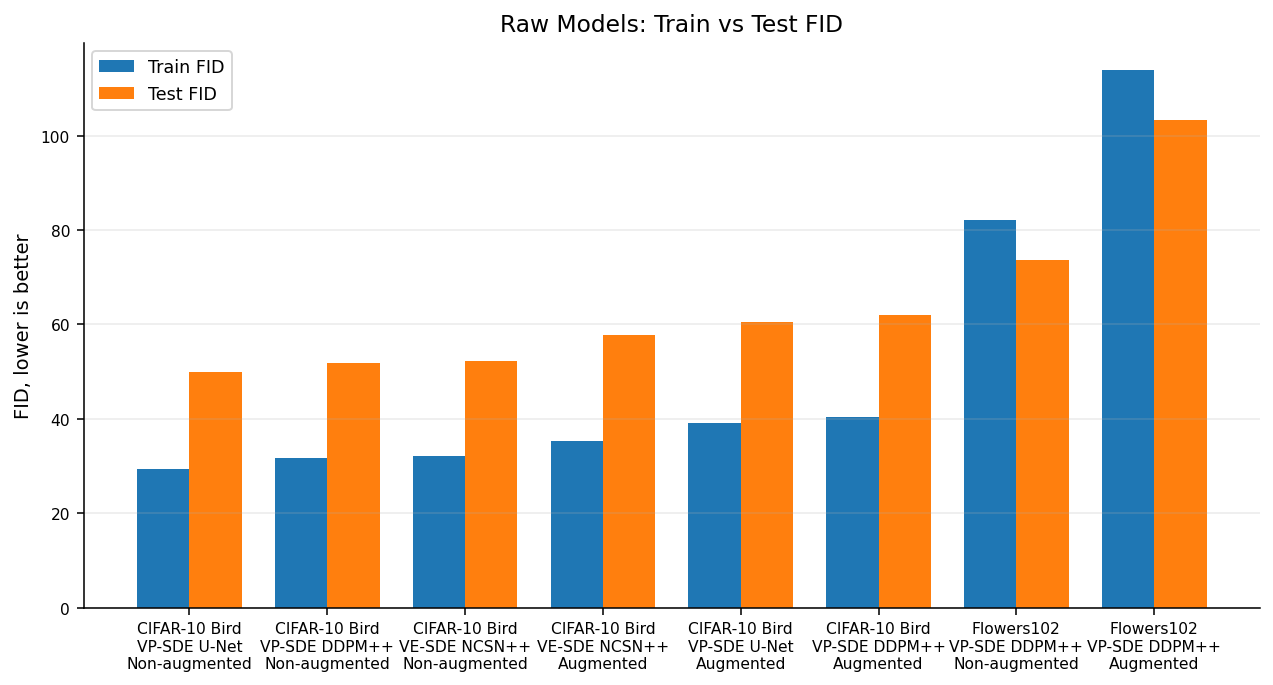

Saved: /content/drive/MyDrive/DD2424/Project/working_nets/report_plots/02_overfitting_index.png


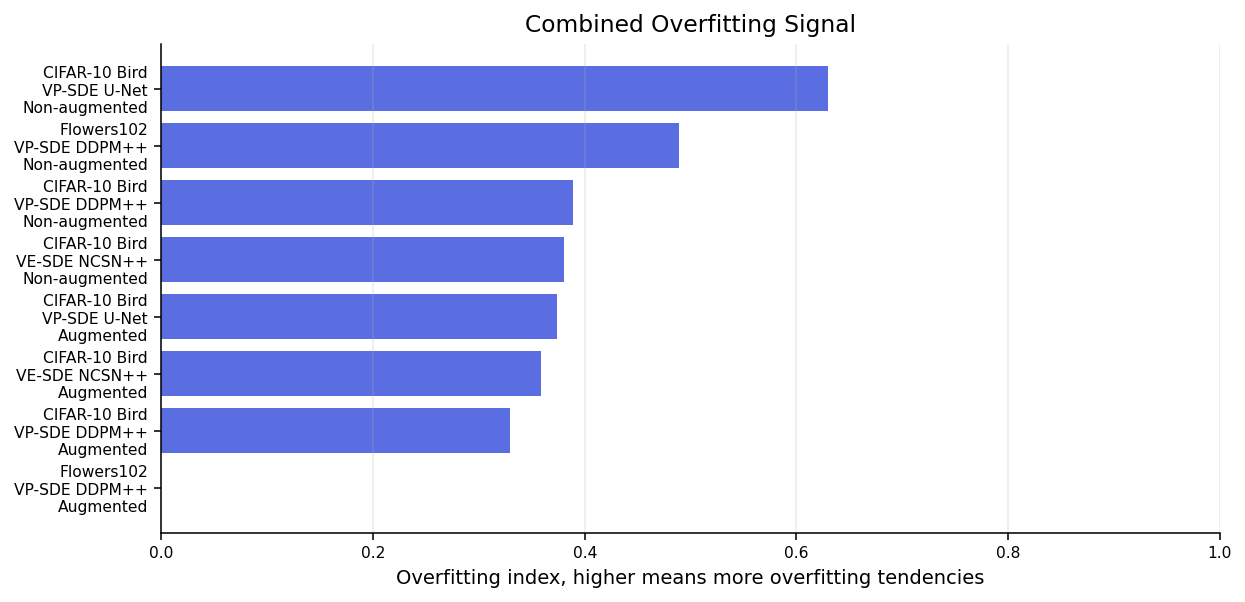

Saved: /content/drive/MyDrive/DD2424/Project/working_nets/report_plots/03_fid_gap_generalization.png


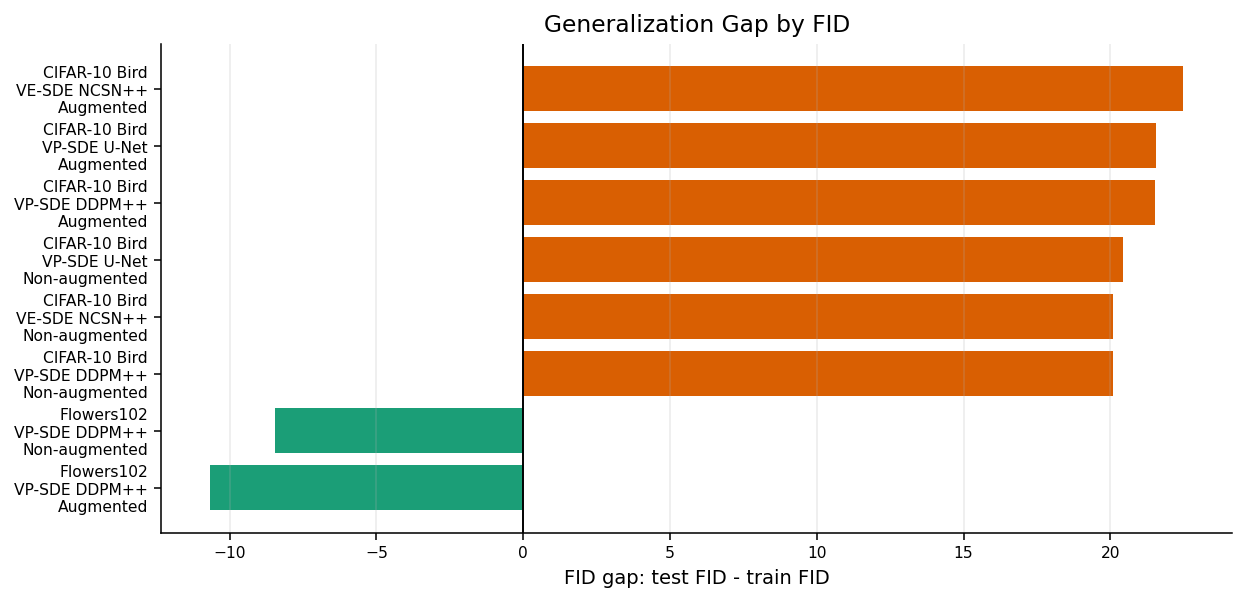

Saved: /content/drive/MyDrive/DD2424/Project/working_nets/report_plots/04_nn_memorization_gap.png


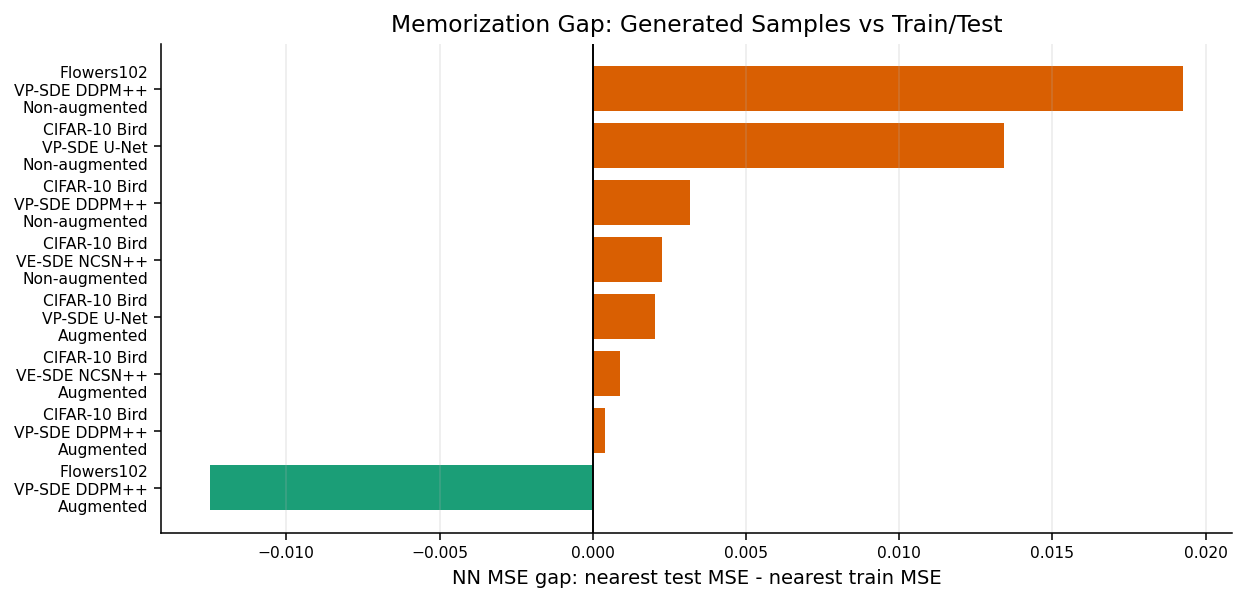

Saved: /content/drive/MyDrive/DD2424/Project/working_nets/report_plots/05_train_closer_fraction.png


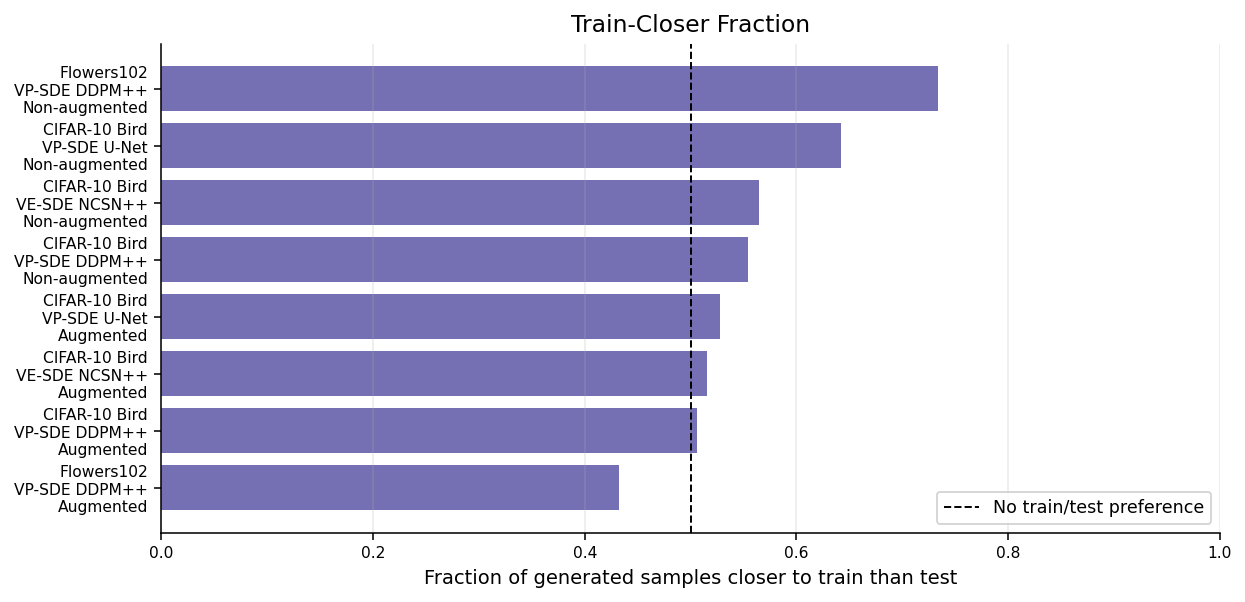

Saved: /content/drive/MyDrive/DD2424/Project/working_nets/report_plots/06_model_size_vs_overfitting.png


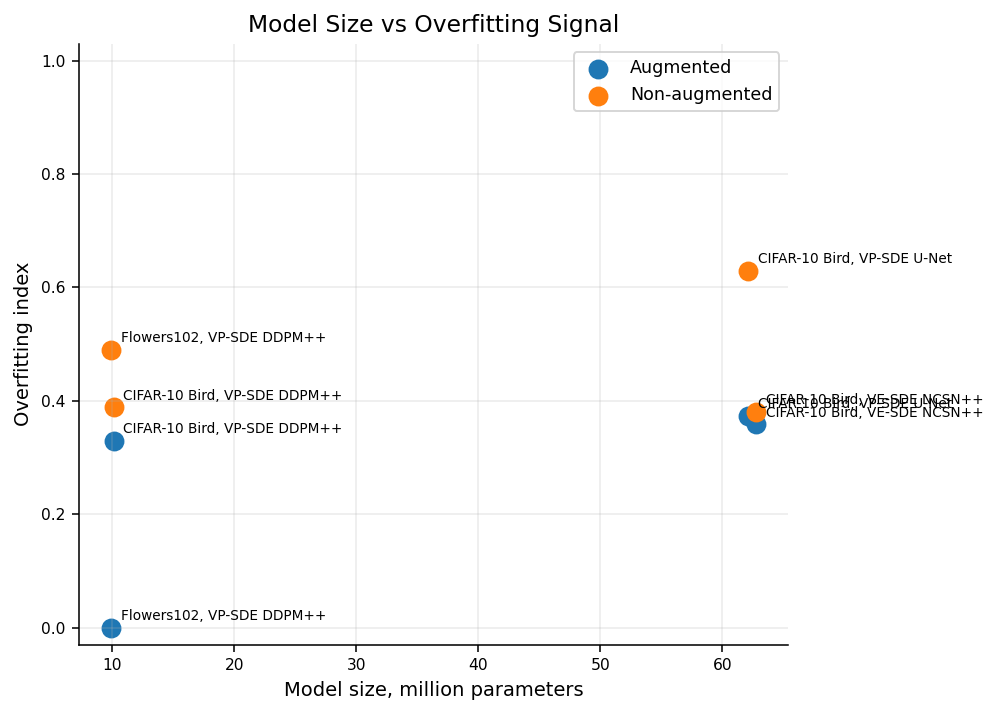

Saved: /content/drive/MyDrive/DD2424/Project/working_nets/report_plots/07_fid_gap_vs_nn_gap.png


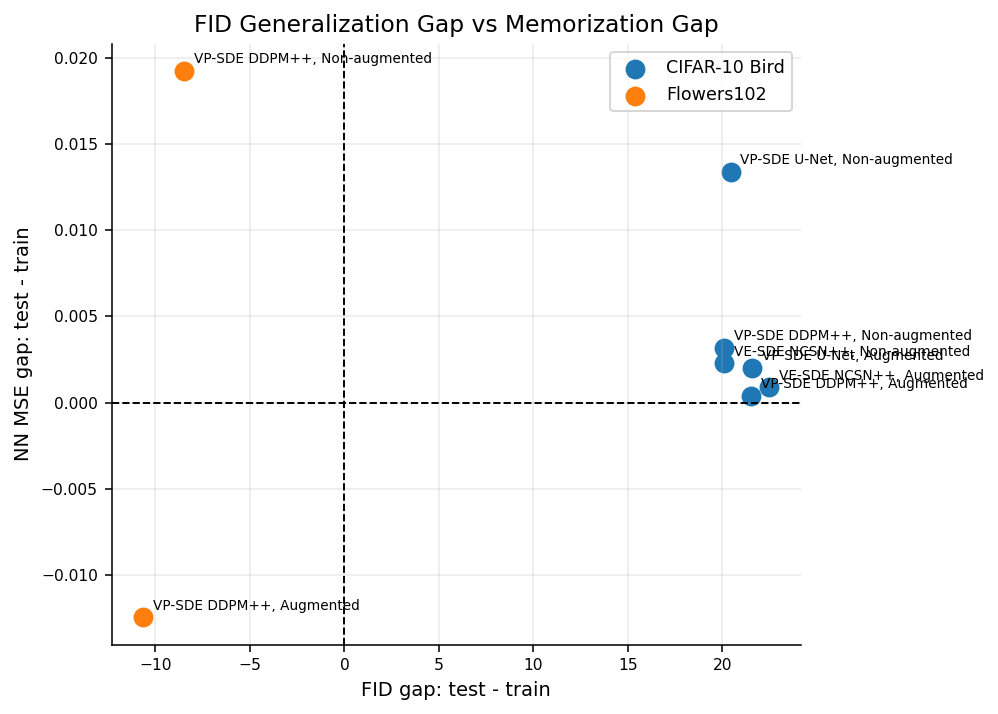


Report interpretation notes:
- Positive FID gap means generated samples match the training split better than the test split.
- Positive NN gap means generated samples are closer in pixel space to train images than to test images.
- Train-closer fraction above 0.5 means more generated samples are closer to train than test.
- The overfitting index combines those three signals; it is comparative, not an absolute proof of memorization.

Most overfitting-like models by combined signal:
- CIFAR-10 Bird | VP-SDE U-Net | Non-augmented: index=0.630, FID gap=20.438, NN gap=0.013415, train-closer=0.642
- Flowers102 | VP-SDE DDPM++ | Non-augmented: index=0.489, FID gap=-8.467, NN gap=0.019270, train-closer=0.734
- CIFAR-10 Bird | VP-SDE DDPM++ | Non-augmented: index=0.389, FID gap=20.076, NN gap=0.003182, train-closer=0.554
- CIFAR-10 Bird | VE-SDE NCSN++ | Non-augmented: index=0.381, FID gap=20.099, NN gap=0.002272, train-closer=0.565
- CIFAR-10 Bird | VP-SDE U-Net | Augmented: index=0.373, FID 

In [6]:
# Report plotting + overfitting analysis cell.
# Requires:
# - all_results from the FID cell, or raw_fid_train_test_results.csv
# - memorization_results from the memorization cell, or raw_memorization_analysis_results.csv

import pandas as pd
import matplotlib.pyplot as plt

PLOT_DIR = os.path.join(PROJECT_PATH, "report_plots")
os.makedirs(PLOT_DIR, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

def savefig(filename):
    out = os.path.join(PLOT_DIR, filename)
    plt.tight_layout()
    plt.savefig(out, bbox_inches="tight")
    print("Saved:", out)
    plt.show()

def readable_model_info(name):
    n = name.lower()

    dataset = "Flowers102" if "flower" in n else "CIFAR-10 Bird"

    if "ve" in n:
        sde = "VE-SDE"
    elif "vp" in n:
        sde = "VP-SDE"
    else:
        sde = "SDE"

    if "unet" in n or "u_net" in n:
        arch = "U-Net"
    elif "ddpmpp" in n:
        arch = "DDPM++"
    elif "ncsnpp" in n:
        arch = "NCSN++"
    else:
        arch = "Model"

    if "non_aug" in n or "non-aug" in n or "non_augmented" in n:
        aug = "Non-augmented"
    elif "augmented" in n:
        aug = "Augmented"
    else:
        aug = "Unknown aug."

        short = f"{dataset}\n{sde} {arch}\n{aug}"
        one_line = f"{dataset} | {sde} {arch} | {aug}"

    return pd.Series({'dataset_label': dataset, 'sde_label': sde, 'arch_label': arch, 'augmentation_label': aug, 'plot_label': short, 'readable_name': one_line})

def positive_minmax(series):
    values = np.maximum(series.astype(float).to_numpy(), 0.0)
    max_value = values.max()
    if max_value <= 1e-12:
        return np.zeros_like(values)
    return values / max_value

# Load results

if "all_results" in globals():
    fid_df = pd.DataFrame(all_results)
else:
    fid_df = pd.read_csv(os.path.join(PROJECT_PATH, "raw_fid_train_test_results.csv"))

if "memorization_results" in globals():
    mem_df = pd.DataFrame(memorization_results)
else:
    mem_df = pd.read_csv(os.path.join(PROJECT_PATH, "raw_memorization_analysis_results.csv"))

if "status" in fid_df.columns:
    fid_df = fid_df[fid_df["status"].fillna("ok") == "ok"].copy()

if "status" in mem_df.columns:
    mem_df = mem_df[mem_df["status"].fillna("ok") == "ok"].copy()

fid_df = pd.concat([fid_df, fid_df["model_name"].apply(readable_model_info)], axis=1)
mem_df = pd.concat([mem_df, mem_df["model_name"].apply(readable_model_info)], axis=1)

if "fid_test_minus_train" not in fid_df.columns:
    fid_df["fid_test_minus_train"] = fid_df["fid_test"] - fid_df["fid_train"]

merged = pd.merge(fid_df, mem_df, on='model_name', how='inner', suffixes=('_fid', '_mem'))

# Overfitting analysis columns

merged["fid_gap"] = merged["fid_test"] - merged["fid_train"]
merged["nn_gap"] = merged["test_nn_mean_mse"] - merged["train_nn_mean_mse"]

merged["fid_gap_interpretation"] = np.where(merged['fid_gap'] > 0, 'test FID worse than train', 'test FID not worse than train')

merged["nn_gap_interpretation"] = np.where(merged['nn_gap'] > 0, 'generated samples closer to train', 'generated samples not closer to train')

merged["train_closer_excess"] = np.maximum(merged['train_closer_than_test_fraction'] - 0.5, 0.0)

merged["fid_gap_signal"] = positive_minmax(merged["fid_gap"])
merged["nn_gap_signal"] = positive_minmax(merged["nn_gap"])
merged["train_closer_signal"] = np.clip(2.0 * merged["train_closer_excess"], 0.0, 1.0)

merged["overfitting_index"] = (
    merged["fid_gap_signal"]
    + merged["nn_gap_signal"]
    + merged["train_closer_signal"]
) / 3.0

merged = merged.sort_values("overfitting_index", ascending=False).reset_index(drop=True)

report_cols = [
    "readable_name_fid",
    "fid_train",
    "fid_test",
    "fid_gap",
    "train_nn_mean_mse",
    "test_nn_mean_mse",
    "nn_gap",
    "train_closer_than_test_fraction",
    "parameter_count_millions",
    "overfitting_index",
]

report_table = merged[report_cols].copy()
report_table = report_table.rename(columns={
    "readable_name_fid": "model",
    "fid_train": "FID train",
    "fid_test": "FID test",
    "fid_gap": "FID gap test-train",
    "train_nn_mean_mse": "NN MSE train",
    "test_nn_mean_mse": "NN MSE test",
    "nn_gap": "NN gap test-train",
    "train_closer_than_test_fraction": "train-closer fraction",
    "parameter_count_millions": "params M",
    "overfitting_index": "overfitting index",
})

display(report_table)

report_csv = os.path.join(PLOT_DIR, "overfitting_report_table.csv")
report_table.to_csv(report_csv, index=False)
print("Saved:", report_csv)

# Plot 1: FID train vs test

plot_df = merged.sort_values("fid_test").copy()
x = np.arange(len(plot_df))
w = 0.38

plt.figure(figsize=(max(8, len(plot_df) * 1.15), 5))
plt.bar(x - w / 2, plot_df["fid_train"], w, label="Train FID")
plt.bar(x + w / 2, plot_df["fid_test"], w, label="Test FID")
plt.xticks(x, plot_df["plot_label_fid"])
plt.ylabel("FID, lower is better")
plt.title("Raw Models: Train vs Test FID")
plt.legend()
plt.grid(axis="y", alpha=0.25)
savefig("01_readable_fid_train_vs_test.png")

# Plot 2: Overfitting indicators

plot_df = merged.sort_values("overfitting_index", ascending=True).copy()

plt.figure(figsize=(9, max(4, len(plot_df) * 0.55)))
plt.barh(plot_df["plot_label_fid"], plot_df["overfitting_index"], color="#5b6ee1")
plt.xlabel("Overfitting index, higher means more overfitting tendencies")
plt.title("Combined Overfitting Signal")
plt.xlim(0, 1)
plt.grid(axis="x", alpha=0.25)
savefig("02_overfitting_index.png")

# Plot 3: FID gap

plot_df = merged.sort_values("fid_gap", ascending=True).copy()
colors = np.where(plot_df["fid_gap"] > 0, "#d95f02", "#1b9e77")

plt.figure(figsize=(9, max(4, len(plot_df) * 0.55)))
plt.barh(plot_df["plot_label_fid"], plot_df["fid_gap"], color=colors)
plt.axvline(0, color="black", linewidth=1)
plt.xlabel("FID gap: test FID - train FID")
plt.title("Generalization Gap by FID")
plt.grid(axis="x", alpha=0.25)
savefig("03_fid_gap_generalization.png")

# Plot 4: Nearest-neighbor memorization gap

plot_df = merged.sort_values("nn_gap", ascending=True).copy()
colors = np.where(plot_df["nn_gap"] > 0, "#d95f02", "#1b9e77")

plt.figure(figsize=(9, max(4, len(plot_df) * 0.55)))
plt.barh(plot_df["plot_label_fid"], plot_df["nn_gap"], color=colors)
plt.axvline(0, color="black", linewidth=1)
plt.xlabel("NN MSE gap: nearest test MSE - nearest train MSE")
plt.title("Memorization Gap: Generated Samples vs Train/Test")
plt.grid(axis="x", alpha=0.25)
savefig("04_nn_memorization_gap.png")

# Plot 5: Train-closer fraction

plot_df = merged.sort_values("train_closer_than_test_fraction", ascending=True).copy()

plt.figure(figsize=(9, max(4, len(plot_df) * 0.55)))
plt.barh(plot_df["plot_label_fid"], plot_df["train_closer_than_test_fraction"], color="#7570b3")
plt.axvline(0.5, color="black", linewidth=1, linestyle="--", label="No train/test preference")
plt.xlabel("Fraction of generated samples closer to train than test")
plt.title("Train-Closer Fraction")
plt.xlim(0, 1)
plt.legend()
plt.grid(axis="x", alpha=0.25)
savefig("05_train_closer_fraction.png")

# Plot 6: Model size vs overfitting index

if "parameter_count_millions" in merged.columns:
    plt.figure(figsize=(7.2, 5.2))

    for aug, sub in merged.groupby("augmentation_label_fid"):
        plt.scatter(sub['parameter_count_millions'], sub['overfitting_index'], s=85, label=aug)

    for _, row in sub.iterrows():
        label=f"{row['dataset_label_fid']}, {row['sde_label_fid']} {row['arch_label_fid']}"
        plt.annotate(label, (row['parameter_count_millions'], row['overfitting_index']), xytext=(5, 4), textcoords='offset points', fontsize=7)

        plt.xlabel("Model size, million parameters")
        plt.ylabel("Overfitting index")
        plt.title("Model Size vs Overfitting Signal")
        plt.ylim(-0.03, 1.03)
        plt.legend()
        plt.grid(alpha=0.25)
        savefig("06_model_size_vs_overfitting.png")

# Plot 7: FID gap vs NN gap

plt.figure(figsize=(7.2, 5.2))

for dataset, sub in merged.groupby("dataset_label_fid"):
    plt.scatter(sub['fid_gap'], sub['nn_gap'], s=85, label=dataset)

    for _, row in sub.iterrows():
        label=f"{row['sde_label_fid']} {row['arch_label_fid']}, {row['augmentation_label_fid']}"
        plt.annotate(label, (row['fid_gap'], row['nn_gap']), xytext=(5, 4), textcoords='offset points', fontsize=7)

plt.axvline(0, color="black", linewidth=1, linestyle="--")
plt.axhline(0, color="black", linewidth=1, linestyle="--")
plt.xlabel("FID gap: test - train")
plt.ylabel("NN MSE gap: test - train")
plt.title("FID Generalization Gap vs Memorization Gap")
plt.legend()
plt.grid(alpha=0.25)
savefig("07_fid_gap_vs_nn_gap.png")

# Text summary for report

print("\nReport interpretation notes:")
print("- Positive FID gap means generated samples match the training split better than the test split.")
print("- Positive NN gap means generated samples are closer in pixel space to train images than to test images.")
print("- Train-closer fraction above 0.5 means more generated samples are closer to train than test.")
print("- The overfitting index combines those three signals; it is comparative, not an absolute proof of memorization.")

print("\nMost overfitting-like models by combined signal:")
for _, row in merged.head(5).iterrows():
    print(
    f"- {row['readable_name_fid']}: "
    f"index={row['overfitting_index']:.3f}, "
    f"FID gap={row['fid_gap']:.3f}, "
    f"NN gap={row['nn_gap']:.6f}, "
    f"train-closer={row['train_closer_than_test_fraction']:.3f}"
    )

print("\nPlots saved in:", PLOT_DIR)


## Corrector-Step Nearest Neighbors


| Dataset        | Model  | SDE | Augmentation | Params (M) | Generated samples | NN gap test − train | Test NN median MSE | Test NN min MSE |
| -------------- | ------ | --- | ------------ | ---------: | ----------------: | ------------------: | -----------------: | --------------: |
| CIFAR-10 Bird  | NCSN++ | VE  | No           |      62.76 |               256 |              0.0024 |             0.0971 |          0.0265 |
| CIFAR-10 Bird  | NCSN++ | VE  | Yes          |      62.76 |               256 |             -0.0004 |             0.0936 |          0.0243 |
| CIFAR-10 Bird  | DDPM++ | VP  | Yes          |      10.09 |               256 |             -0.0002 |             0.0860 |          0.0263 |
| CIFAR-10 Bird  | DDPM++ | VP  | No           |      10.09 |               256 |              0.0041 |             0.0771 |          0.0245 |
| CIFAR-10 Bird  | U-Net  | VP  | Yes          |      62.14 |               256 |              0.0002 |             0.1103 |          0.0284 |
| CIFAR-10 Bird  | U-Net  | VP  | No           |      62.14 |               256 |              0.0120 |             0.0591 |          0.0143 |
| Oxford Flowers | DDPM++ | VP  | Yes          |       9.89 |               256 |             -0.0120 |             0.1954 |          0.0868 |
| Oxford Flowers | DDPM++ | VP  | No           |       9.89 |               256 |              0.0212 |             0.1305 |          0.0451 |


## Zero-Corrector Nearest Neighbors


| Dataset        | Model  | SDE | Augmentation | Params (M) | Generated samples | NN gap test − train | Test NN median MSE | Test NN min MSE | Count < 0.01 |
| -------------- | ------ | --- | ------------ | ---------: | ----------------: | ------------------: | -----------------: | --------------: | -----------: |
| Oxford Flowers | DDPM++ | VP  | No           |       9.89 |               256 |            0.015953 |           0.133079 |        0.048897 |            0 |
| CIFAR-10 Bird  | U-Net  | VP  | No           |      62.14 |               256 |            0.011684 |           0.056412 |        0.016711 |            0 |
| CIFAR-10 Bird  | NCSN++ | VE  | No           |      62.76 |               256 |            0.002437 |           0.097061 |        0.026506 |            0 |
| CIFAR-10 Bird  | DDPM++ | VP  | No           |      10.09 |               256 |            0.002762 |           0.082516 |        0.021626 |            0 |
| CIFAR-10 Bird  | U-Net  | VP  | Yes          |      62.14 |               256 |            0.001803 |           0.120932 |        0.024248 |            0 |
| CIFAR-10 Bird  | DDPM++ | VP  | Yes          |      10.09 |               256 |           -0.000220 |           0.097743 |        0.025418 |            0 |
| CIFAR-10 Bird  | NCSN++ | VE  | Yes          |      62.76 |               256 |           -0.001608 |           0.096392 |        0.022599 |            0 |
| Oxford Flowers | DDPM++ | VP  | Yes          |       9.89 |               256 |           -0.013768 |           0.197282 |        0.082543 |            0 |


## Combined Nearest-Neighbor Summary


| Dataset        | Model  | SDE | Augmentation | Corrector | Params (M) | Generated samples | NN gap test − train | Test NN median MSE | Test NN min MSE |
| -------------- | ------ | --- | ------------ | --------: | ---------: | ----------------: | ------------------: | -----------------: | --------------: |
| CIFAR-10 Bird  | NCSN++ | VE  | No           |         1 |      62.76 |               256 |            0.002400 |           0.097100 |        0.026500 |
| CIFAR-10 Bird  | NCSN++ | VE  | Yes          |         1 |      62.76 |               256 |           -0.000400 |           0.093600 |        0.024300 |
| CIFAR-10 Bird  | DDPM++ | VP  | Yes          |         1 |      10.09 |               256 |           -0.000200 |           0.086000 |        0.026300 |
| CIFAR-10 Bird  | DDPM++ | VP  | No           |         1 |      10.09 |               256 |            0.004100 |           0.077100 |        0.024500 |
| CIFAR-10 Bird  | U-Net  | VP  | Yes          |         1 |      62.14 |               256 |            0.000200 |           0.110300 |        0.028400 |
| CIFAR-10 Bird  | U-Net  | VP  | No           |         1 |      62.14 |               256 |            0.012000 |           0.059100 |        0.014300 |
| Oxford Flowers | DDPM++ | VP  | Yes          |         1 |       9.89 |               256 |           -0.012000 |           0.195400 |        0.086800 |
| Oxford Flowers | DDPM++ | VP  | No           |         1 |       9.89 |               256 |            0.021200 |           0.130500 |        0.045100 |
| Oxford Flowers | DDPM++ | VP  | No           |         0 |       9.89 |               256 |            0.015953 |           0.133079 |        0.048897 |
| CIFAR-10 Bird  | U-Net  | VP  | No           |         0 |      62.14 |               256 |            0.011684 |           0.056412 |        0.016711 |
| CIFAR-10 Bird  | NCSN++ | VE  | No           |         0 |      62.76 |               256 |            0.002437 |           0.097061 |        0.026506 |
| CIFAR-10 Bird  | DDPM++ | VP  | No           |         0 |      10.09 |               256 |            0.002762 |           0.082516 |        0.021626 |
| CIFAR-10 Bird  | U-Net  | VP  | Yes          |         0 |      62.14 |               256 |            0.001803 |           0.120932 |        0.024248 |
| CIFAR-10 Bird  | DDPM++ | VP  | Yes          |         0 |      10.09 |               256 |           -0.000220 |           0.097743 |        0.025418 |
| CIFAR-10 Bird  | NCSN++ | VE  | Yes          |         0 |      62.76 |               256 |           -0.001608 |           0.096392 |        0.022599 |
| Oxford Flowers | DDPM++ | VP  | Yes          |         0 |       9.89 |               256 |           -0.013768 |           0.197282 |        0.082543 |


| Model                            | Augmented | FID train | FID test | Δ FID test − train |
| -------------------------------- | :-------: | --------: | -------: | -----------------: |
| Bird VE-SDE NCSN++, Epoch 1760   |     No    |    63.654 |   62.949 |             -0.705 |
| Bird VE-SDE NCSN++, Epoch 1760   |    Yes    |    69.430 |   68.876 |             -0.554 |
| Bird VP-SDE DDPM++, Epoch 1760   |    Yes    |    73.205 |   73.846 |              0.641 |
| Bird VP-SDE DDPM++, Epoch 1760   |     No    |    62.638 |   63.175 |              0.537 |
| Bird VP-SDE U-Net, Epoch 1760    |    Yes    |    71.355 |   71.561 |              0.206 |
| Bird VP-SDE U-Net, Epoch 1760    |     No    |    57.910 |   59.301 |              1.391 |
| Flower VP-SDE DDPM++, Epoch 1760 |    Yes    |   122.153 |  128.439 |              6.286 |
| Flower VP-SDE DDPM++, Epoch 1760 |     No    |    88.813 |   96.011 |              7.198 |





| Dataset        | Model  | SDE | Augmentation | Corrector steps | FID train | FID test |   ΔFID |
| -------------- | ------ | --- | ------------ | --------------: | --------: | -------: | -----: |
| CIFAR-10 Bird  | NCSN++ | VE  | No           |               0 |    63.654 |   62.949 | -0.705 |
| CIFAR-10 Bird  | NCSN++ | VE  | Yes          |               0 |    69.430 |   68.876 | -0.554 |
| CIFAR-10 Bird  | DDPM++ | VP  | Yes          |               0 |    73.205 |   73.846 |  0.641 |
| CIFAR-10 Bird  | DDPM++ | VP  | No           |               0 |    62.638 |   63.175 |  0.537 |
| CIFAR-10 Bird  | U-Net  | VP  | Yes          |               0 |    71.355 |   71.561 |  0.206 |
| CIFAR-10 Bird  | U-Net  | VP  | No           |               0 |    57.910 |   59.301 |  1.391 |
| Oxford Flowers | DDPM++ | VP  | Yes          |               0 |   122.153 |  128.439 |  6.286 |
| Oxford Flowers | DDPM++ | VP  | No           |               0 |    88.813 |   96.011 |  7.198 |
| CIFAR-10 Bird  | NCSN++ | VE  | No           |               1 |     63.66 |    62.95 |  -0.70 |
| CIFAR-10 Bird  | NCSN++ | VE  | Yes          |               1 |     69.38 |    69.17 |  -0.20 |
| CIFAR-10 Bird  | DDPM++ | VP  | Yes          |               1 |     74.50 |    74.84 |   0.34 |
| CIFAR-10 Bird  | DDPM++ | VP  | No           |               1 |     62.76 |    63.23 |   0.47 |
| CIFAR-10 Bird  | U-Net  | VP  | Yes          |               1 |     71.65 |    71.64 |  -0.01 |
| CIFAR-10 Bird  | U-Net  | VP  | No           |               1 |     58.54 |    60.60 |   2.06 |
| Oxford Flowers | DDPM++ | VP  | Yes          |               1 |    120.85 |   127.26 |   6.41 |
| Oxford Flowers | DDPM++ | VP  | No           |               1 |     89.48 |    96.37 |   6.90 |


## Nearest-Neighbor Figure


VP sampling:   0%|          | 0/999 [00:00<?, ?it/s]

VP sampling:   0%|          | 0/999 [00:00<?, ?it/s]

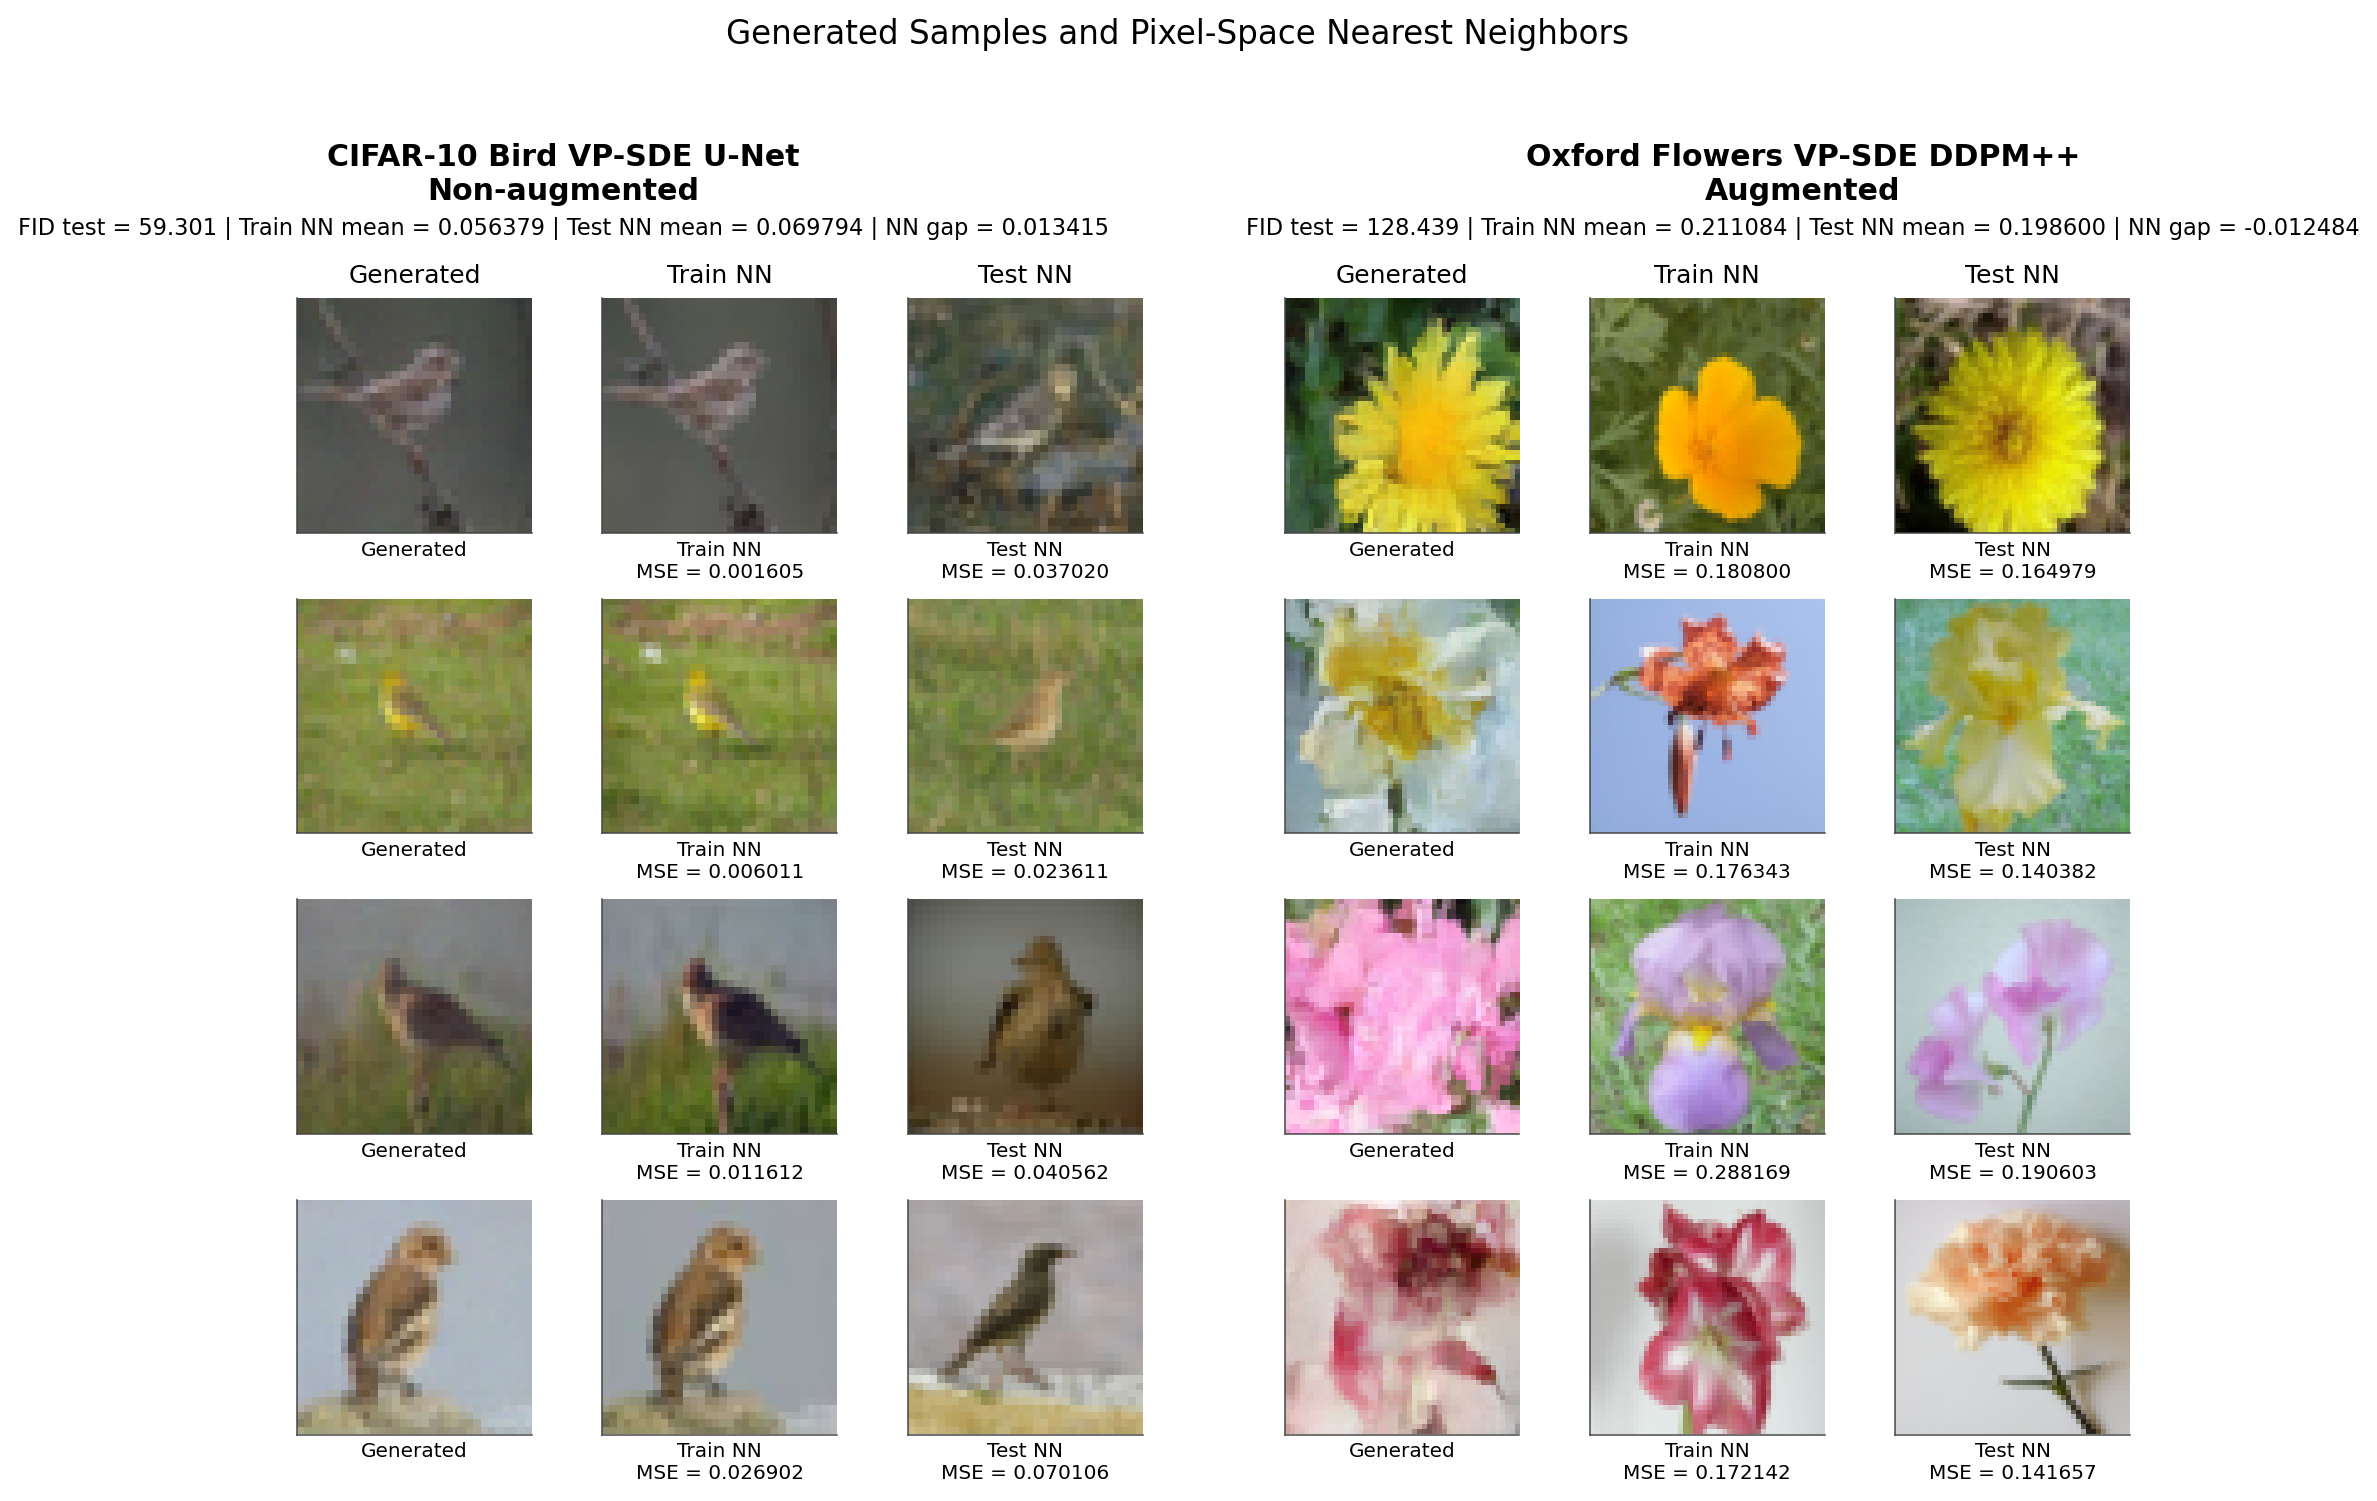

Saved nearest-neighbor figure: /content/drive/MyDrive/DD2424/Project/working_nets/report_nearest_neighbor_figures/nearest_neighbor_triplets_bird_unet_vs_flowers_ddpmpp.png


In [7]:
# Compact nearest-neighbor triplet figure for two selected raw models.
# Requires the original FID/model-loading cell to have been run first.


NN_FIGURE_DIR = os.path.join(PROJECT_PATH, "report_nearest_neighbor_figures")
os.makedirs(NN_FIGURE_DIR, exist_ok=True)

NN_FIGURE_PATH = os.path.join(
    NN_FIGURE_DIR,
    "nearest_neighbor_triplets_bird_unet_vs_flowers_ddpmpp.png"
)

NN_NUM_SAMPLES_PER_MODEL = 4
NN_REFERENCE_MAX_IMAGES = 5000
NN_SAMPLE_STEPS = 1000
NN_SAMPLE_EPS = 1e-3
NN_SAMPLE_SNR = 0.01

# Set this to 1 if you want the figure generated with one corrector step.
NN_CORRECTOR_STEPS = 0

NN_SEED = 123
NN_REF_BATCH_SIZE = 512

SELECTED_NN_MODELS = [
    {
        "model_name": "bird_vp_unet_non_augmented_raw_1760",
        "title": "CIFAR-10 Bird VP-SDE U-Net\nNon-augmented",
        "subtitle": (
            "FID test = 59.301 | "
            "Train NN mean = 0.056379 | "
            "Test NN mean = 0.069794 | "
            "NN gap = 0.013415"
        ),
    },
    {
        "model_name": "flower_vp_ddpmpp_augmented_raw_1760",
        "title": "Oxford Flowers VP-SDE DDPM++\nAugmented",
        "subtitle": (
            "FID test = 128.439 | "
            "Train NN mean = 0.211084 | "
            "Test NN mean = 0.198600 | "
            "NN gap = -0.012484"
        ),
    },
]

required = [
    "MODEL_SPECS",
    "PROJECT_PATH",
    "device",
    "torch_load_checkpoint",
    "build_model",
    "select_raw_state_dict",
    "load_raw_state",
    "get_plain_data_loaders",
    "sample_vp_sde",
]

missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError("Run the original FID cell first. Missing: " + ", ".join(missing))


def denormalize_image(x):
    return (x / 2.0 + 0.5).clamp(0, 1)


def image_for_plot(x):
    x = denormalize_image(x.detach().cpu())
    return x.permute(1, 2, 0).numpy()


def get_spec_by_name(model_name):
    for spec in MODEL_SPECS:
        if spec["name"] == model_name:
            return spec
    raise KeyError(f"Model spec not found: {model_name}")


def load_raw_model(spec):
    checkpoint_path = os.path.join(PROJECT_PATH, spec["checkpoint"])
    if not os.path.exists(checkpoint_path):
        raise FileNotFoundError(checkpoint_path)

    checkpoint = torch_load_checkpoint(checkpoint_path)
    model, meta = build_model(spec, checkpoint)

    raw_state = select_raw_state_dict(checkpoint, spec["raw_keys"])
    load_raw_state(model, raw_state)

    model.eval()
    for p in model.parameters():
        p.requires_grad_(False)

    return model, meta


@torch.no_grad()
def generate_four_samples(model, spec, meta):
    torch.manual_seed(NN_SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(NN_SEED)

    if meta["sde"] != "vp":
        raise ValueError("This figure cell is written for the two selected VP-SDE models.")

    samples = sample_vp_sde(net=model, num_samples=NN_NUM_SAMPLES_PER_MODEL, img_shape=meta["image_shape"],
        num_steps=NN_SAMPLE_STEPS, eps=NN_SAMPLE_EPS, snr=NN_SAMPLE_SNR, corrector_steps=NN_CORRECTOR_STEPS,
        beta_min=meta["beta_min"], beta_max=meta["beta_max"], denoise=True)

    return samples.detach().cpu()


@torch.no_grad()
def collect_reference_images(loader, max_images):
    chunks = []
    count = 0

    for images, _ in loader:
        chunks.append(images.cpu())
        count += images.shape[0]

        if count >= max_images:
            break

    return torch.cat(chunks, dim=0)[:max_images]


@torch.no_grad()
def nearest_neighbors_pixel_mse(generated_images, reference_images):
    generated_images = generated_images.cpu()
    reference_images = reference_images.cpu()

    n_generated = generated_images.shape[0]
    n_reference = reference_images.shape[0]
    dim=generated_images[0].numel()

    gen_flat = generated_images.reshape(n_generated, -1).to(device)

    best_distances = torch.full((n_generated,), float("inf"), device=device)
    best_indices = torch.zeros((n_generated,), dtype=torch.long, device=device)

    for start in range(0, n_reference, NN_REF_BATCH_SIZE):
        end = min(start + NN_REF_BATCH_SIZE, n_reference)

        ref_batch = reference_images[start:end].to(device)
        ref_flat = ref_batch.reshape(ref_batch.shape[0], -1)

        dists = torch.cdist(gen_flat, ref_flat, p=2) ** 2
        dists = dists / dim

        min_dists, min_idx = dists.min(dim=1)
        better = min_dists < best_distances

        best_distances[better] = min_dists[better]
        best_indices[better] = start + min_idx[better]

    nn_images = reference_images[best_indices.cpu()]
    return nn_images.cpu(), best_distances.cpu()


def prepare_triplet_block(model_info):
    spec = get_spec_by_name(model_info["model_name"])

    model, meta = load_raw_model(spec)
    generated = generate_four_samples(model, spec, meta)

    model.to("cpu")
    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    loaders = get_plain_data_loaders(spec["dataset"], spec["image_size"])

    train_refs = collect_reference_images(loaders["train"], NN_REFERENCE_MAX_IMAGES)
    test_refs = collect_reference_images(loaders["test"], NN_REFERENCE_MAX_IMAGES)

    train_nn, train_mse = nearest_neighbors_pixel_mse(generated, train_refs)
    test_nn, test_mse = nearest_neighbors_pixel_mse(generated, test_refs)

    return {
        "info": model_info,
        "generated": generated,
        "train_nn": train_nn,
        "test_nn": test_nn,
        "train_mse": train_mse,
        "test_mse": test_mse,
    }


blocks = [prepare_triplet_block(info) for info in SELECTED_NN_MODELS]

# Plot compact side-by-side figure

fig = plt.figure(figsize=(13.5, 8.2), dpi=180)

# 4 rows, 7 columns: left triplet, spacer, right triplet.
gs = fig.add_gridspec(nrows=4, ncols=7, width_ratios=[1, 1, 1, 0.18, 1, 1, 1], wspace=0.08, hspace=0.28)

left_cols = [0, 1, 2]
right_cols = [4, 5, 6]
col_titles = ["Generated", "Train NN", "Test NN"]

for block_idx, block in enumerate(blocks):
    cols = left_cols if block_idx == 0 else right_cols

    for row in range(NN_NUM_SAMPLES_PER_MODEL):
        images = [
            block["generated"][row],
            block["train_nn"][row],
            block["test_nn"][row],
        ]

        labels = [
            "Generated",
            f"Train NN\nMSE = {block['train_mse'][row].item():.6f}",
            f"Test NN\nMSE = {block['test_mse'][row].item():.6f}",
        ]

        for j, col in enumerate(cols):
            ax = fig.add_subplot(gs[row, col])
            ax.imshow(image_for_plot(images[j]))
            ax.set_xticks([])
            ax.set_yticks([])

            if row == 0:
                ax.set_title(col_titles[j], fontsize=10, pad=6)

            ax.set_xlabel(labels[j], fontsize=8, labelpad=3)

            for spine in ax.spines.values():
                spine.set_linewidth(0.6)
                spine.set_color("#444444")

# Block titles
fig.text(0.245, 0.985, blocks[0]["info"]["title"], ha="center", va="top", fontsize=12, fontweight="bold")
fig.text(0.245, 0.935, blocks[0]["info"]["subtitle"], ha="center", va="top", fontsize=9)

fig.text(0.755, 0.985, blocks[1]["info"]["title"], ha="center", va="top", fontsize=12, fontweight="bold")
fig.text(0.755, 0.935, blocks[1]["info"]["subtitle"], ha="center", va="top", fontsize=9)

fig.suptitle(f"Generated Samples and Pixel-Space Nearest Neighbors ", y=1.07, fontsize=13)

plt.savefig(NN_FIGURE_PATH, bbox_inches="tight", pad_inches=0.12)
plt.show()

print("Saved nearest-neighbor figure:", NN_FIGURE_PATH)


## Corrector-Step Results


In [1]:
# Single Colab cell:
# FID sweep for bird VP U-Net non-augmented raw model
# corrector_steps=1, 2, 3, 4


# Settings

PROJECT_PATH = "/content/drive/MyDrive/DD2424/Project/working_nets"

CHECKPOINT_NAME = "bird_vp_sde_checkpoint_1760_epochs.pth"
MODEL_NAME_BASE = "bird_vp_unet_non_augmented_raw_1760"

CORRECTOR_STEPS_TO_SWEEP = [1, 2, 3, 4]

FID_NUM_GENERATED = 1000
FID_GEN_BATCH_SIZE = 500
FID_REAL_MAX_IMAGES = 1000

SAMPLE_NUM_STEPS = 1000
SAMPLE_EPS = 1e-3
SAMPLE_SNR = 0.01
RANDOM_SEED = 0

BATCH_SIZE = 128
FID_FEATURE = 2048
SHOW_SAMPLING_PROGRESS = True

IMAGE_SIZE = 32
IMAGE_SHAPE = (3, IMAGE_SIZE, IMAGE_SIZE)

BETA_MIN = 0.1
BETA_MAX = 20.0

# Install dependencies

subprocess.check_call([
    sys.executable, "-m", "pip", "install", "-q",
    "torchmetrics", "torch-fidelity"
])

try:
    from google.colab import drive
    try:
        drive.mount("/content/drive")
    except ValueError:
        pass
except Exception:
    pass


device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

torch.backends.cudnn.benchmark = True

# Data: CIFAR-10 bird only

def get_cifar10_bird_loaders():
    pin_memory=torch.cuda.is_available()

    transform_plain = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(
            (0.5, 0.5, 0.5),
            (0.5, 0.5, 0.5)
        )
    ])

    train_full = torchvision.datasets.CIFAR10(root="./data", train=True, download=True, transform=transform_plain)

    target_idx = train_full.classes.index("bird")

    train_indices = [
        i for i, label in enumerate(train_full.targets)
        if label == target_idx
    ]

    trainset = Subset(train_full, train_indices)

    test_full = torchvision.datasets.CIFAR10(root="./data", train=False, download=True, transform=transform_plain)

    test_indices = [
        i for i, label in enumerate(test_full.targets)
        if label == target_idx
    ]

    testset = Subset(test_full, test_indices)

    trainloader = DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=pin_memory)

    testloader = DataLoader(testset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=pin_memory)

    print("Dataset: CIFAR-10 bird")
    print("Training bird images:", len(trainset))
    print("Test bird images:", len(testset))

    return trainloader, testloader

# VP U-Net model

class SinusoidalTimeEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim=dim

    def forward(self, t):
        half = self.dim // 2
        emb = math.log(10000) / (half - 1)
        emb = torch.exp(torch.arange(half, device=t.device) * -emb)
        emb = t[:, None] * emb[None, :]
        emb = torch.cat([torch.sin(emb), torch.cos(emb)], dim=1)
        return emb


class SelfAttention(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.norm = nn.GroupNorm(32, ch)
        self.q = nn.Conv2d(ch, ch, 1)
        self.k = nn.Conv2d(ch, ch, 1)
        self.v = nn.Conv2d(ch, ch, 1)
        self.proj = nn.Conv2d(ch, ch, 1)

    def forward(self, x):
        B, C, H, W = x.shape
        h = self.norm(x)

        q = self.q(h).reshape(B, C, H * W).permute(0, 2, 1)
        k = self.k(h).reshape(B, C, H * W)
        v = self.v(h).reshape(B, C, H * W)

        attn = torch.softmax(q @ k / math.sqrt(C), dim=-1)
        out = (v @ attn.permute(0, 2, 1)).reshape(B, C, H, W)

        return x + self.proj(out)


class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, emb_dim):
        super().__init__()

        self.norm1 = nn.GroupNorm(32, in_ch)
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)

        self.norm2 = nn.GroupNorm(32, out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)

        self.emb_proj = nn.Linear(emb_dim, out_ch * 2)
        self.act = nn.SiLU()

        if in_ch != out_ch:
            self.skip = nn.Conv2d(in_ch, out_ch, 1)
        else:
            self.skip = nn.Identity()

    def forward(self, x, emb):
        h = self.conv1(self.act(self.norm1(x)))

        scale, shift = self.emb_proj(emb).chunk(2, dim=1)
        scale = scale[:, :, None, None]
        shift = shift[:, :, None, None]

        h = self.norm2(h)
        h = h * (1 + scale) + shift
        h = self.conv2(self.act(h))

        return h + self.skip(x)


class Downsample(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.conv = nn.Conv2d(ch, ch, 4, 2, 1)

    def forward(self, x):
        return self.conv(x)


class Upsample(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.conv = nn.ConvTranspose2d(ch, ch, 4, 2, 1)

    def forward(self, x):
        return self.conv(x)


class UNet(nn.Module):
    def __init__(self, img_ch=3, base_ch=128):
        super().__init__()

        emb_dim = base_ch * 4

        self.time_emb = SinusoidalTimeEmbedding(emb_dim)
        self.emb_mlp = nn.Sequential(
            nn.Linear(emb_dim, emb_dim),
            nn.SiLU(),
            nn.Linear(emb_dim, emb_dim)
        )

        self.conv_in = nn.Conv2d(img_ch, base_ch, 3, padding=1)

        self.down1 = ResBlock(base_ch, 128, emb_dim)
        self.ds0 = Downsample(128)

        self.down2 = ResBlock(128, 256, emb_dim)
        self.ds1 = Downsample(256)

        self.down3 = ResBlock(256, 512, emb_dim)
        self.attn16 = SelfAttention(512)
        self.ds2 = Downsample(512)

        self.down4 = ResBlock(512, 512, emb_dim)
        self.attn8 = SelfAttention(512)

        self.mid1 = ResBlock(512, 512, emb_dim)
        self.mid_attn = SelfAttention(512)
        self.mid2 = ResBlock(512, 512, emb_dim)

        self.up4 = ResBlock(1024, 512, emb_dim)
        self.attn8_up = SelfAttention(512)
        self.us2 = Upsample(512)

        self.up3 = ResBlock(1024, 512, emb_dim)
        self.attn16_up = SelfAttention(512)
        self.us1 = Upsample(512)

        self.up2 = ResBlock(768, 256, emb_dim)
        self.us0 = Upsample(256)

        self.up1 = ResBlock(384, 128, emb_dim)

        self.conv_out = nn.Conv2d(128, img_ch, 3, padding=1)

    def forward(self, x, t):
        emb = self.emb_mlp(self.time_emb(t * 999.0))

        x = self.conv_in(x)

        d1 = self.down1(x, emb)
        d1_down = self.ds0(d1)

        d2 = self.down2(d1_down, emb)
        d2_down = self.ds1(d2)

        d3 = self.down3(d2_down, emb)
        d3 = self.attn16(d3)
        d3_down = self.ds2(d3)

        d4 = self.down4(d3_down, emb)
        d4 = self.attn8(d4)

        mid = self.mid1(d4, emb)
        mid = self.mid_attn(mid)
        mid = self.mid2(mid, emb)

        u4 = self.up4(torch.cat([mid, d4], dim=1), emb)
        u4 = self.attn8_up(u4)
        u4_up = self.us2(u4)

        u3 = self.up3(torch.cat([u4_up, d3], dim=1), emb)
        u3 = self.attn16_up(u3)
        u3_up = self.us1(u3)

        u2 = self.up2(torch.cat([u3_up, d2], dim=1), emb)
        u2_up = self.us0(u2)

        u1 = self.up1(torch.cat([u2_up, d1], dim=1), emb)

        return self.conv_out(u1)

# VP SDE functions

def beta_t(t, beta_min=BETA_MIN, beta_max=BETA_MAX):
    return beta_min + t * (beta_max - beta_min)


@torch.no_grad()
def langevin_corrector_vp(x, t, net, snr=SAMPLE_SNR, n_steps=1, eps=1e-12):
    B = x.shape[0]
    batch_t = torch.ones(B, device=x.device) * t

    x_mean = x

    for _ in range(n_steps):
        score = net(x, batch_t)
        noise = torch.randn_like(x)

        score_norm = torch.norm(score.reshape(B, -1), dim=1).mean()
        noise_norm = torch.norm(noise.reshape(B, -1), dim=1).mean()

        step_size = 2.0 * (snr * noise_norm / (score_norm + eps)) ** 2

        x_mean = x + step_size * score
        x = x_mean + torch.sqrt(2.0 * step_size) * noise

    return x, x_mean


@torch.no_grad()
def euler_maruyama_predictor_vp(x, t, t_next, net, beta_min=BETA_MIN, beta_max=BETA_MAX, add_noise=True):
    B = x.shape[0]
    h = t - t_next
    batch_t = torch.ones(B, device=x.device) * t

    beta = beta_t(batch_t, beta_min=beta_min, beta_max=beta_max).view(-1, 1, 1, 1)

    score = net(x, batch_t)

    drift = 0.5 * beta * x + beta * score
    x_mean = x + drift * h

    if add_noise:
        noise = torch.randn_like(x)
        x = x_mean + torch.sqrt(beta * h) * noise
    else:
        x = x_mean

    return x, x_mean


@torch.no_grad()
def sample_vp_sde(net, num_samples, img_shape, num_steps, eps, snr, corrector_steps, beta_min, beta_max, denoise=True):
    net.eval()

    x = torch.randn(num_samples, *img_shape, device=device)
    timesteps = torch.linspace(1.0, eps, num_steps, device=device)

    x_mean = x

    iterator = tqdm(range(num_steps - 1), desc=f"VP sampling, corrector_steps={corrector_steps}", leave=False, disable=not SHOW_SAMPLING_PROGRESS)

    for i in iterator:
        t = timesteps[i]
        t_next = timesteps[i + 1]

        if corrector_steps > 0:
            x, x_mean = langevin_corrector_vp(x=x, t=t, net=net, snr=snr, n_steps=corrector_steps)

        add_noise = i < num_steps - 2

        x, x_mean = euler_maruyama_predictor_vp(x=x, t=t, t_next=t_next, net=net, beta_min=beta_min, beta_max=beta_max, add_noise=add_noise)

    if denoise:
        return x_mean.clamp(-1, 1)
    else:
        return x.clamp(-1, 1)

# Checkpoint loading

def torch_load_checkpoint(checkpoint_path):
    try:
        return torch.load(checkpoint_path, map_location="cpu", weights_only=False)
    except TypeError:
        return torch.load(
            checkpoint_path,
            map_location="cpu"
        )


def select_raw_state_dict(checkpoint):
    raw_keys = ["vp_net"]

    if isinstance(checkpoint, dict):
        for key in raw_keys:
            if key in checkpoint:
                return checkpoint[key]

        if all(torch.is_tensor(v) for v in checkpoint.values()):
            return checkpoint

    raise KeyError(f"Could not find raw VP U-Net weights. Tried keys: {raw_keys}")


def strip_prefix_if_present(state_dict, prefix):
    keys = list(state_dict.keys())

    if len(keys) > 0 and all(k.startswith(prefix) for k in keys):
        return {
            k[len(prefix):]: v
            for k, v in state_dict.items()
        }

    return state_dict


def clean_state_dict(state_dict):
    state_dict = strip_prefix_if_present(state_dict, "module.")
    state_dict = strip_prefix_if_present(state_dict, "_orig_mod.")
    return state_dict


def load_raw_state(model, state_dict):
    state_dict = clean_state_dict(state_dict)
    model.load_state_dict(state_dict, strict=True)

# FID helpers

def denormalize(x):
    return (x / 2 + 0.5).clamp(0, 1)


def to_uint8_images(x):
    x = denormalize(x)
    x = (x * 255.0).round().clamp(0, 255)
    return x.to(torch.uint8)


@torch.no_grad()
def generate_samples(model, corrector_steps):
    torch.manual_seed(RANDOM_SEED)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(RANDOM_SEED)

    all_samples = []
    generated = 0

    while generated < FID_NUM_GENERATED:
        current_batch = min(
            FID_GEN_BATCH_SIZE,
            FID_NUM_GENERATED - generated
        )

        samples = sample_vp_sde(net=model, num_samples=current_batch, img_shape=IMAGE_SHAPE, num_steps=SAMPLE_NUM_STEPS,
            eps=SAMPLE_EPS, snr=SAMPLE_SNR, corrector_steps=corrector_steps, beta_min=BETA_MIN, beta_max=BETA_MAX,
            denoise=True)

        all_samples.append(samples.detach().cpu())

        generated += current_batch
        print(f"Generated samples: {generated}/{FID_NUM_GENERATED}")

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    return torch.cat(all_samples, dim=0)


@torch.no_grad()
def compute_fid_from_generated(generated_samples, real_loader, real_name):
    fid = FrechetInceptionDistance(
        feature=FID_FEATURE,
        normalize=False
    ).to(device)

    real_count = 0

    for real_images, _ in real_loader:
        if FID_REAL_MAX_IMAGES is not None:
            remaining = FID_REAL_MAX_IMAGES - real_count

            if remaining <= 0:
                break

            real_images = real_images[:remaining]

        real_images = real_images.to(device)
        real_images_uint8 = to_uint8_images(real_images)

        fid.update(real_images_uint8, real=True)

        real_count += real_images.shape[0]

        if FID_REAL_MAX_IMAGES is not None and real_count >= FID_REAL_MAX_IMAGES:
            break

    print(f"Real {real_name} images added to FID:", real_count)

    gen_count = 0

    for start in range(0, generated_samples.shape[0], FID_GEN_BATCH_SIZE):
        end = min(
            start + FID_GEN_BATCH_SIZE,
            generated_samples.shape[0]
        )

        gen_batch = generated_samples[start:end].to(device)
        gen_batch_uint8 = to_uint8_images(gen_batch)

        fid.update(gen_batch_uint8, real=False)

        gen_count += gen_batch.shape[0]

        print(
            f"Generated images added to {real_name} FID: "
            f"{gen_count}/{generated_samples.shape[0]}"
        )

    fid_value = fid.compute().item()

    del fid
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return fid_value, real_count

# Evaluation

def load_model_from_checkpoint():
    checkpoint_path = os.path.join(PROJECT_PATH, CHECKPOINT_NAME)

    if not os.path.exists(checkpoint_path):
        raise FileNotFoundError(f"Checkpoint not found: {checkpoint_path}")

    print("Loading checkpoint:", checkpoint_path)

    checkpoint = torch_load_checkpoint(checkpoint_path)

    model=UNet().to(device)
    model.eval()

    for p in model.parameters():
        p.requires_grad_(False)

    raw_state = select_raw_state_dict(checkpoint)
    load_raw_state(model, raw_state)

    del checkpoint
    del raw_state
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return model


def evaluate_corrector_steps(corrector_steps, train_loader, test_loader):
    run_name = f"{MODEL_NAME_BASE}_corrector{corrector_steps}"

    print("\n====================================")
    print("Model:", run_name)
    print("Corrector steps:", corrector_steps)
    print("====================================")

    model=load_model_from_checkpoint()

    generated_samples = generate_samples(
        model=model,
        corrector_steps=corrector_steps
    )

    model.to("cpu")
    del model
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    fid_train, train_real_count = compute_fid_from_generated(generated_samples=generated_samples, real_loader=train_loader, real_name="training")

    fid_test, test_real_count = compute_fid_from_generated(generated_samples=generated_samples, real_loader=test_loader, real_name="test")

    fid_gap = fid_test - fid_train
    fid_abs_gap = abs(fid_gap)

    result = {
        "model_name": run_name,
        "corrector_steps": corrector_steps,
        "fid_train": fid_train,
        "fid_test": fid_test,
        "fid_test_minus_train": fid_gap,
        "fid_abs_difference": fid_abs_gap,
        "train_real_images_used": train_real_count,
        "test_real_images_used": test_real_count,
        "generated_images_used": generated_samples.shape[0],
    }

    print("\nFID results:")
    print(f"model_name: {result['model_name']}")
    print(f"corrector_steps: {result['corrector_steps']}")
    print(f"fid_train: {result['fid_train']:.6f}")
    print(f"fid_test: {result['fid_test']:.6f}")
    print(f"fid_test_minus_train: {result['fid_test_minus_train']:.6f}")
    print(f"fid_abs_difference: {result['fid_abs_difference']:.6f}")

    del generated_samples
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return result

# Run sweep

train_loader, test_loader = get_cifar10_bird_loaders()

all_results = []

for corrector_steps in CORRECTOR_STEPS_TO_SWEEP:
    result = evaluate_corrector_steps(corrector_steps=corrector_steps, train_loader=train_loader, test_loader=test_loader)

    all_results.append(result)

print("\n====================================")
print("Final FID summary")
print("====================================")

for result in all_results:
    print(
        f"{result['model_name']} | "
        f"corrector_steps={result['corrector_steps']} | "
        f"FID train={result['fid_train']:.6f} | "
        f"FID test = {result['fid_test']:.6f} | "
        f"FID gap test-train={result['fid_test_minus_train']:.6f} | "
        f"abs gap = {result['fid_abs_difference']:.6f}"
    )

all_results


Mounted at /content/drive
Using device: cuda


100%|██████████| 170M/170M [00:06<00:00, 27.5MB/s]


Dataset: CIFAR-10 bird
Training bird images: 5000
Test bird images: 1000

Model: bird_vp_unet_non_augmented_raw_1760_corrector1
Corrector steps: 1
Loading checkpoint: /content/drive/MyDrive/DD2424/Project/working_nets/bird_vp_sde_checkpoint_1760_epochs.pth


VP sampling, corrector_steps=1:   0%|          | 0/999 [00:00<?, ?it/s]

Generated samples: 500/1000


...

VP sampling, corrector_steps=4:   0%|          | 0/999 [00:00<?, ?it/s]

Generated samples: 500/1000


VP sampling, corrector_steps=4:   0%|          | 0/999 [00:00<?, ?it/s]

Generated samples: 1000/1000
Real training images added to FID: 1000
Generated images added to training FID: 500/1000
Generated images added to training FID: 1000/1000
Real test images added to FID: 1000
Generated images added to test FID: 500/1000
Generated images added to test FID: 1000/1000

FID results:
model_name: bird_vp_unet_non_augmented_raw_1760_corrector4
corrector_steps: 4
fid_train: 59.108295
fid_test: 60.324295
fid_test_minus_train: 1.216000
fid_abs_difference: 1.216000

Final FID summary
bird_vp_unet_non_augmented_raw_1760_corrector1 | corrector_steps = 1 | FID train = 59.408962 | FID test = 61.199226 | FID gap test-train = 1.790264 | abs gap = 1.790264
bird_vp_unet_non_augmented_raw_1760_corrector2 | corrector_steps = 2 | FID train = 58.919724 | FID test = 60.641270 | FID gap test-train = 1.721546 | abs gap = 1.721546
bird_vp_unet_non_augmented_raw_1760_corrector3 | corrector_steps = 3 | FID train = 58.859650 | FID test = 60.865963 | FID gap test-train = 2.006313 | abs g

[{'model_name': 'bird_vp_unet_non_augmented_raw_1760_corrector1',
  'corrector_steps': 1,
  'fid_train': 59.40896224975586,
  'fid_test': 61.19922637939453,
  'fid_test_minus_train': 1.7902641296386719,
  'fid_abs_difference': 1.7902641296386719,
  'train_real_images_used': 1000,
  'test_real_images_used': 1000,
  'generated_images_used': 1000},
 {'model_name': 'bird_vp_unet_non_augmented_raw_1760_corrector2',
  'corrector_steps': 2,
  'fid_train': 58.91972351074219,
  'fid_test': 60.64126968383789,
  'fid_test_minus_train': 1.7215461730957031,
  'fid_abs_difference': 1.7215461730957031,
  'train_real_images_used': 1000,
  'test_real_images_used': 1000,
  'generated_images_used': 1000},
 {'model_name': 'bird_vp_unet_non_augmented_raw_1760_corrector3',
  'corrector_steps': 3,
  'fid_train': 58.859649658203125,
  'fid_test': 60.865962982177734,
  'fid_test_minus_train': 2.0063133239746094,
  'fid_abs_difference': 2.0063133239746094,
  'train_real_images_used': 1000,
  'test_real_images_u

## Corrector-Step Memorization


In [3]:
# Separate Colab cell:
# Memorization / overfitting analysis for
# bird_vp_unet_non_augmented_raw_1760
# with corrector_steps=1, 2, 3, 4


# Memorization settings

MEM_NUM_GENERATED = 1000
MEM_GEN_BATCH_SIZE = 1000
MEM_NUM_STEPS = 1000
MEM_EPS = 1e-3
MEM_SNR = 0.01

# Collect a larger pool, then compare against equal-size random train/test subsets.
MEM_REFERENCE_POOL_IMAGES = 5000
MEM_REFERENCE_COMPARE_IMAGES = 1000

NN_GEN_BATCH_SIZE = 64
NN_REF_BATCH_SIZE = 512

MEM_RANDOM_SEED = 0

SAVE_MEM_RESULTS_CSV = False
MEM_RESULTS_CSV = os.path.join(
    PROJECT_PATH,
    "vp_unet_non_augmented_corrector_sweep_memorization_results.csv"
)

COPY_MSE_THRESHOLDS = [1e-4, 1e-3, 1e-2]

# Corrector steps to evaluate
MEM_CORRECTOR_STEPS_TO_SWEEP = [1, 2, 3, 4]

# Checks

required_names = [
    "PROJECT_PATH",
    "CHECKPOINT_NAME",
    "MODEL_NAME_BASE",
    "device",
    "IMAGE_SHAPE",
    "BETA_MIN",
    "BETA_MAX",
    "UNet",
    "load_model_from_checkpoint",
    "sample_vp_sde",
    "get_cifar10_bird_loaders",
]

missing = [name for name in required_names if name not in globals()]

if missing:
    raise RuntimeError(
        "Run the VP U-Net FID/corrector-sweep cell first. "
        "Missing definitions: " + ", ".join(missing)
    )

# Helpers

def count_parameters(model):
    return sum(p.numel() for p in model.parameters())


@torch.no_grad()
def collect_reference_images(loader, max_images):
    chunks = []
    count = 0

    for images, _ in loader:
        chunks.append(images.cpu())
        count += images.shape[0]

        if count >= max_images:
            break

    images = torch.cat(chunks, dim=0)
    return images[:max_images]


def random_subset_images(images, n, seed):
    n = min(n, images.shape[0])

    generator = torch.Generator()
    generator.manual_seed(seed)

    indices = torch.randperm(
        images.shape[0],
        generator=generator
    )[:n]

    return images[indices]


@torch.no_grad()
def generate_mem_samples(model, corrector_steps):
    torch.manual_seed(MEM_RANDOM_SEED)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(MEM_RANDOM_SEED)

    all_samples = []
    generated = 0

    while generated < MEM_NUM_GENERATED:
        current_batch = min(
            MEM_GEN_BATCH_SIZE,
            MEM_NUM_GENERATED - generated
        )

        samples = sample_vp_sde(net=model, num_samples=current_batch, img_shape=IMAGE_SHAPE, num_steps=MEM_NUM_STEPS,
            eps=MEM_EPS, snr=MEM_SNR, corrector_steps=corrector_steps, beta_min=BETA_MIN, beta_max=BETA_MAX,
            denoise=True)

        all_samples.append(samples.detach().cpu())

        generated += current_batch

        print(
            f"Generated samples for memorization "
            f"corrector_steps={corrector_steps}: "
            f"{generated}/{MEM_NUM_GENERATED}"
        )

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    return torch.cat(all_samples, dim=0)


@torch.no_grad()
def nearest_neighbor_pixel_mse(generated_images, reference_images):
    generated_images = generated_images.cpu()
    reference_images = reference_images.cpu()

    n_generated = generated_images.shape[0]
    n_reference = reference_images.shape[0]
    dim=generated_images[0].numel()

    best_distances = torch.full((n_generated,), float("inf"), device=device)

    best_indices = torch.zeros((n_generated,), dtype=torch.long, device=device)

    for gen_start in range(0, n_generated, NN_GEN_BATCH_SIZE):
        gen_end = min(
            gen_start + NN_GEN_BATCH_SIZE,
            n_generated
        )

        gen_batch = generated_images[gen_start:gen_end].to(device)
        gen_flat = gen_batch.reshape(gen_batch.shape[0], -1)

        local_best_distances = torch.full((gen_batch.shape[0],), float("inf"), device=device)

        local_best_indices = torch.zeros((gen_batch.shape[0],), dtype=torch.long, device=device)

        for ref_start in range(0, n_reference, NN_REF_BATCH_SIZE):
            ref_end = min(
                ref_start + NN_REF_BATCH_SIZE,
                n_reference
            )

            ref_batch = reference_images[ref_start:ref_end].to(device)
            ref_flat = ref_batch.reshape(ref_batch.shape[0], -1)

            dists = torch.cdist(gen_flat, ref_flat, p=2) ** 2
            dists = dists / dim

            min_dists, min_idx = dists.min(dim=1)

            better = min_dists < local_best_distances

            local_best_distances[better] = min_dists[better]
            local_best_indices[better] = ref_start + min_idx[better]

        best_distances[gen_start:gen_end] = local_best_distances
        best_indices[gen_start:gen_end] = local_best_indices

    return best_indices.cpu(), best_distances.cpu()


def summarize_distances(prefix, distances):
    values = distances.numpy()

    summary = {
        f"{prefix}_mean_mse": float(values.mean()),
        f"{prefix}_median_mse": float(np.median(values)),
        f"{prefix}_min_mse": float(values.min()),
        f"{prefix}_p01_mse": float(np.percentile(values, 1)),
        f"{prefix}_p05_mse": float(np.percentile(values, 5)),
        f"{prefix}_p10_mse": float(np.percentile(values, 10)),
        f"{prefix}_p90_mse": float(np.percentile(values, 90)),
        f"{prefix}_max_mse": float(values.max()),
    }

    for threshold in COPY_MSE_THRESHOLDS:
        key = f"{prefix}_count_under_{threshold:g}"
        summary[key] = int((values < threshold).sum())

    return summary


def analyze_corrector_step_memorization(corrector_steps, train_ref, test_ref, reference_n):
    run_name = f"{MODEL_NAME_BASE}_corrector{corrector_steps}"

    print("\n====================================")
    print("Memorization analysis")
    print("Model:", run_name)
    print("Corrector steps:", corrector_steps)
    print("Checkpoint:", os.path.join(PROJECT_PATH, CHECKPOINT_NAME))
    print("====================================")

    model=load_model_from_checkpoint()

    model.eval()
    for p in model.parameters():
        p.requires_grad_(False)

    param_count = count_parameters(model)
    param_count_millions = param_count / 1e6

    print(f"Parameter count: {param_count_millions:.3f}M")

    generated = generate_mem_samples(
        model=model,
        corrector_steps=corrector_steps
    )

    model.to("cpu")
    del model

    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    print("Generated samples:", generated.shape[0])
    print("Train references used:", train_ref.shape[0])
    print("Test references used:", test_ref.shape[0])

    train_nn_indices, train_nn_distances = nearest_neighbor_pixel_mse(
        generated,
        train_ref
    )

    test_nn_indices, test_nn_distances = nearest_neighbor_pixel_mse(
        generated,
        test_ref
    )

    train_values = train_nn_distances.numpy()
    test_values = test_nn_distances.numpy()

    mean_gap = float(test_values.mean() - train_values.mean())
    median_gap = float(np.median(test_values) - np.median(train_values))

    mean_ratio = float(
        train_values.mean() / (test_values.mean() + 1e-12)
    )

    median_ratio = float(
        np.median(train_values) / (np.median(test_values) + 1e-12)
    )

    train_closer_fraction = float(
        (train_values < test_values).mean()
    )

    result = {
        "model_name": run_name,
        "checkpoint": os.path.join(PROJECT_PATH, CHECKPOINT_NAME),
        "dataset": "cifar10_bird",
        "model_type": "vp_unet",
        "sde": "vp",
        "corrector_steps": int(corrector_steps),
        "parameter_count": int(param_count),
        "parameter_count_millions": float(param_count_millions),
        "generated_samples": int(generated.shape[0]),
        "reference_images_per_split": int(reference_n),
        "nn_gap_mean_test_minus_train": mean_gap,
        "nn_gap_median_test_minus_train": median_gap,
        "nn_ratio_train_over_test_mean": mean_ratio,
        "nn_ratio_train_over_test_median": median_ratio,
        "train_closer_than_test_fraction": train_closer_fraction,
        "status": "ok",
    }

    result.update(
        summarize_distances(
            "train_nn",
            train_nn_distances
        )
    )

    result.update(
        summarize_distances(
            "test_nn",
            test_nn_distances
        )
    )

    print("\nMemorization summary:")
    print(f"corrector_steps: {corrector_steps}")
    print(f"train NN mean MSE: {result['train_nn_mean_mse']:.8f}")
    print(f"test  NN mean MSE: {result['test_nn_mean_mse']:.8f}")
    print(f"mean gap, test - train: {mean_gap:.8f}")
    print(f"median gap, test - train: {median_gap:.8f}")
    print(f"train/test mean ratio: {mean_ratio:.4f}")
    print(f"train/test median ratio: {median_ratio:.4f}")
    print(f"fraction closer to train than test: {train_closer_fraction:.4f}")

    for threshold in COPY_MSE_THRESHOLDS:
        train_key = f"train_nn_count_under_{threshold:g}"
        test_key = f"test_nn_count_under_{threshold:g}"

        print(
            f"copies under MSE {threshold:g}: "
            f"train={result[train_key]}, "
            f"test={result[test_key]}"
        )

    del generated
    del train_nn_indices
    del test_nn_indices
    del train_nn_distances
    del test_nn_distances

    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return result


# Prepare fixed train/test references

train_loader, test_loader = get_cifar10_bird_loaders()

train_pool = collect_reference_images(
    train_loader,
    MEM_REFERENCE_POOL_IMAGES
)

test_pool = collect_reference_images(
    test_loader,
    MEM_REFERENCE_POOL_IMAGES
)

reference_n = min(MEM_REFERENCE_COMPARE_IMAGES, train_pool.shape[0], test_pool.shape[0])

train_ref = random_subset_images(train_pool, reference_n, MEM_RANDOM_SEED + 11)

test_ref = random_subset_images(test_pool, reference_n, MEM_RANDOM_SEED + 29)

print("\nFixed reference sets prepared")
print("Train reference pool:", train_pool.shape[0])
print("Test reference pool:", test_pool.shape[0])
print("Train references used:", train_ref.shape[0])
print("Test references used:", test_ref.shape[0])

del train_pool
del test_pool

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# Run corrector-step memorization sweep

memorization_results = []

for corrector_steps in MEM_CORRECTOR_STEPS_TO_SWEEP:
    result = analyze_corrector_step_memorization(corrector_steps=corrector_steps, train_ref=train_ref, test_ref=test_ref, reference_n=reference_n)

    memorization_results.append(result)

print("\n====================================")
print("Final corrector-step memorization summary")
print("====================================")

for row in memorization_results:
    if row.get("status") != "ok":
        print(f"{row['model_name']} | {row['status']}")
        continue

    print(
        f"{row['model_name']} | "
        f"corrector_steps={row['corrector_steps']} | "
        f"params={row['parameter_count_millions']:.2f}M | "
        f"train_nn_mean={row['train_nn_mean_mse']:.6f} | "
        f"test_nn_mean={row['test_nn_mean_mse']:.6f} | "
        f"gap(test-train)={row['nn_gap_mean_test_minus_train']:.6f} | "
        f"train_closer_frac={row['train_closer_than_test_fraction']:.3f}"
    )

try:
    import pandas as pd

    memorization_df = pd.DataFrame(memorization_results)

    ok_df = memorization_df[
        memorization_df["status"] == "ok"
    ].copy()

    ok_df = ok_df.sort_values(
        ["corrector_steps"],
        ascending=True
    )

    display(ok_df)

    if SAVE_MEM_RESULTS_CSV:
        memorization_df.to_csv(
            MEM_RESULTS_CSV,
            index=False
        )

        print("Saved memorization analysis CSV:", MEM_RESULTS_CSV)

    if len(ok_df) >= 2:
        print("\nCorrelation with corrector steps:")
        print(
            "corrector steps vs train NN mean:",
            ok_df["corrector_steps"].corr(
                ok_df["train_nn_mean_mse"]
            ),
        )
        print(
            "corrector steps vs test NN mean:",
            ok_df["corrector_steps"].corr(
                ok_df["test_nn_mean_mse"]
            ),
        )
        print(
            "corrector steps vs train-closer fraction:",
            ok_df["corrector_steps"].corr(
                ok_df["train_closer_than_test_fraction"]
            ),
        )
        print(
            "corrector steps vs gap(test-train):",
            ok_df["corrector_steps"].corr(
                ok_df["nn_gap_mean_test_minus_train"]
            ),
        )

except Exception as e:
    print("Pandas display/save skipped:", repr(e))

memorization_results


Dataset: CIFAR-10 bird
Training bird images: 5000
Test bird images: 1000

Fixed reference sets prepared
Train reference pool: 5000
Test reference pool: 1000
Train references used: 1000
Test references used: 1000

Memorization analysis
Model: bird_vp_unet_non_augmented_raw_1760_corrector1
Corrector steps: 1
Checkpoint: /content/drive/MyDrive/DD2424/Project/working_nets/bird_vp_sde_checkpoint_1760_epochs.pth
Loading checkpoint: /content/drive/MyDrive/DD2424/Project/working_nets/bird_vp_sde_checkpoint_1760_epochs.pth
Parameter count: 62.140M


VP sampling, corrector_steps=1:   0%|          | 0/999 [00:00<?, ?it/s]

Generated samples for memorization corrector_steps=1: 1000/1000
Generated samples: 1000
Train references used: 1000
Test references used: 1000

Memorization summary:
corrector_steps: 1
train NN mean MSE: 0.05442576
test  NN mean MSE: 0.06616489
mean gap, test - train: 0.01173913
median gap, test - train: 0.01024205
train/test mean ratio: 0.8226
train/test median ratio: 0.8067
fraction closer to train than test: 0.6630
copies under MSE 0.0001: train=0, test=0
copies under MSE 0.001: train=0, test=0
copies under MSE 0.01: train=91, test=0

Memorization analysis
Model: bird_vp_unet_non_augmented_raw_1760_corrector2
Corrector steps: 2
Checkpoint: /content/drive/MyDrive/DD2424/Project/working_nets/bird_vp_sde_checkpoint_1760_epochs.pth
Loading checkpoint: /content/drive/MyDrive/DD2424/Project/working_nets/bird_vp_sde_checkpoint_1760_epochs.pth
Parameter count: 62.140M


VP sampling, corrector_steps=2:   0%|          | 0/999 [00:00<?, ?it/s]

Generated samples for memorization corrector_steps=2: 1000/1000
Generated samples: 1000
Train references used: 1000
Test references used: 1000

Memorization summary:
corrector_steps: 2
train NN mean MSE: 0.05361151
test  NN mean MSE: 0.06550311
mean gap, test - train: 0.01189159
median gap, test - train: 0.01192507
train/test mean ratio: 0.8185
train/test median ratio: 0.7797
fraction closer to train than test: 0.6480
copies under MSE 0.0001: train=0, test=0
copies under MSE 0.001: train=0, test=0
copies under MSE 0.01: train=97, test=0

Memorization analysis
Model: bird_vp_unet_non_augmented_raw_1760_corrector3
Corrector steps: 3
Checkpoint: /content/drive/MyDrive/DD2424/Project/working_nets/bird_vp_sde_checkpoint_1760_epochs.pth
Loading checkpoint: /content/drive/MyDrive/DD2424/Project/working_nets/bird_vp_sde_checkpoint_1760_epochs.pth
Parameter count: 62.140M


...

VP sampling, corrector_steps=4:   0%|          | 0/999 [00:00<?, ?it/s]

Generated samples for memorization corrector_steps=4: 1000/1000
Generated samples: 1000
Train references used: 1000
Test references used: 1000

Memorization summary:
corrector_steps: 4
train NN mean MSE: 0.05481231
test  NN mean MSE: 0.06960052
mean gap, test - train: 0.01478821
median gap, test - train: 0.01263196
train/test mean ratio: 0.7875
train/test median ratio: 0.7716
fraction closer to train than test: 0.6280
copies under MSE 0.0001: train=0, test=0
copies under MSE 0.001: train=0, test=0
copies under MSE 0.01: train=97, test=0

Final corrector-step memorization summary
bird_vp_unet_non_augmented_raw_1760_corrector1 | corrector_steps=1 | params=62.14M | train_nn_mean=0.054426 | test_nn_mean=0.066165 | gap(test-train)=0.011739 | train_closer_frac=0.663
bird_vp_unet_non_augmented_raw_1760_corrector2 | corrector_steps=2 | params=62.14M | train_nn_mean=0.053612 | test_nn_mean=0.065503 | gap(test-train)=0.011892 | train_closer_frac=0.648
bird_vp_unet_non_augmented_raw_1760_correcto

,model_name,checkpoint,dataset,model_type,sde,corrector_steps,parameter_count,parameter_count_millions,generated_samples,reference_images_per_split,...,test_nn_median_mse,test_nn_min_mse,test_nn_p01_mse,test_nn_p05_mse,test_nn_p10_mse,test_nn_p90_mse,test_nn_max_mse,test_nn_count_under_0.0001,test_nn_count_under_0.001,test_nn_count_under_0.01
0,bird_vp_unet_non_augmented_raw_1760_corrector1,/content/drive/MyDrive/DD2424/Project/working_...,cifar10_bird,vp_unet,vp,1,62140291,62.140291,1000,1000,...,0.052977,0.011748,0.018629,0.022270,0.025610,0.125915,0.295649,0,0,0
1,bird_vp_unet_non_augmented_raw_1760_corrector2,/content/drive/MyDrive/DD2424/Project/working_...,cifar10_bird,vp_unet,vp,2,62140291,62.140291,1000,1000,...,0.054138,0.013176,0.017783,0.022807,0.026969,0.119705,0.244681,0,0,0
2,bird_vp_unet_non_augmented_raw_1760_corrector3,/content/drive/MyDrive/DD2424/Project/working_...,cifar10_bird,vp_unet,vp,3,62140291,62.140291,1000,1000,...,0.053890,0.012685,0.015779,0.021985,0.025889,0.130128,0.311122,0,0,0
3,bird_vp_unet_non_augmented_raw_1760_corrector4,/content/drive/MyDrive/DD2424/Project/working_...,cifar10_bird,vp_unet,vp,4,62140291,62.140291,1000,1000,...,0.055310,0.012149,0.016681,0.021888,0.025956,0.136753,0.381512,0,0,0



Correlation with corrector steps:
corrector steps vs train NN mean: 0.523258465123848
corrector steps vs test NN mean: 0.8418223400583502
corrector steps vs train-closer fraction: -0.9838699100999073
corrector steps vs gap(test-train): 0.7716694688599428


[{'model_name': 'bird_vp_unet_non_augmented_raw_1760_corrector1',
  'checkpoint': '/content/drive/MyDrive/DD2424/Project/working_nets/bird_vp_sde_checkpoint_1760_epochs.pth',
  'dataset': 'cifar10_bird',
  'model_type': 'vp_unet',
  'sde': 'vp',
  'corrector_steps': 1,
  'parameter_count': 62140291,
  'parameter_count_millions': 62.140291,
  'generated_samples': 1000,
  'reference_images_per_split': 1000,
  'nn_gap_mean_test_minus_train': 0.011739131063222885,
  'nn_gap_median_test_minus_train': 0.010242052376270294,
  'nn_ratio_train_over_test_mean': 0.8225776553153992,
  'nn_ratio_train_over_test_median': 0.8066710233688354,
  'train_closer_than_test_fraction': 0.663,
  'status': 'ok',
  'train_nn_mean_mse': 0.05442575737833977,
  'train_nn_median_mse': 0.0427352674305439,
  'train_nn_min_mse': 0.0010870000114664435,
  'train_nn_p01_mse': 0.002405160339549184,
  'train_nn_p05_mse': 0.004961438477039337,
  'train_nn_p10_mse': 0.011339736171066761,
  'train_nn_p90_mse': 0.1143167167901

## Corrector-Step Samples


Loading checkpoint: /content/drive/MyDrive/DD2424/Project/working_nets/bird_vp_sde_checkpoint_1760_epochs.pth
Generating 5 samples with corrector_steps=0


VP sampling, corrector_steps=0:   0%|          | 0/999 [00:00<?, ?it/s]

Generating 5 samples with corrector_steps=1


VP sampling, corrector_steps=1:   0%|          | 0/999 [00:00<?, ?it/s]

Generating 5 samples with corrector_steps=2


VP sampling, corrector_steps=2:   0%|          | 0/999 [00:00<?, ?it/s]

Generating 5 samples with corrector_steps=3


VP sampling, corrector_steps=3:   0%|          | 0/999 [00:00<?, ?it/s]

Generating 5 samples with corrector_steps=4


VP sampling, corrector_steps=4:   0%|          | 0/999 [00:00<?, ?it/s]

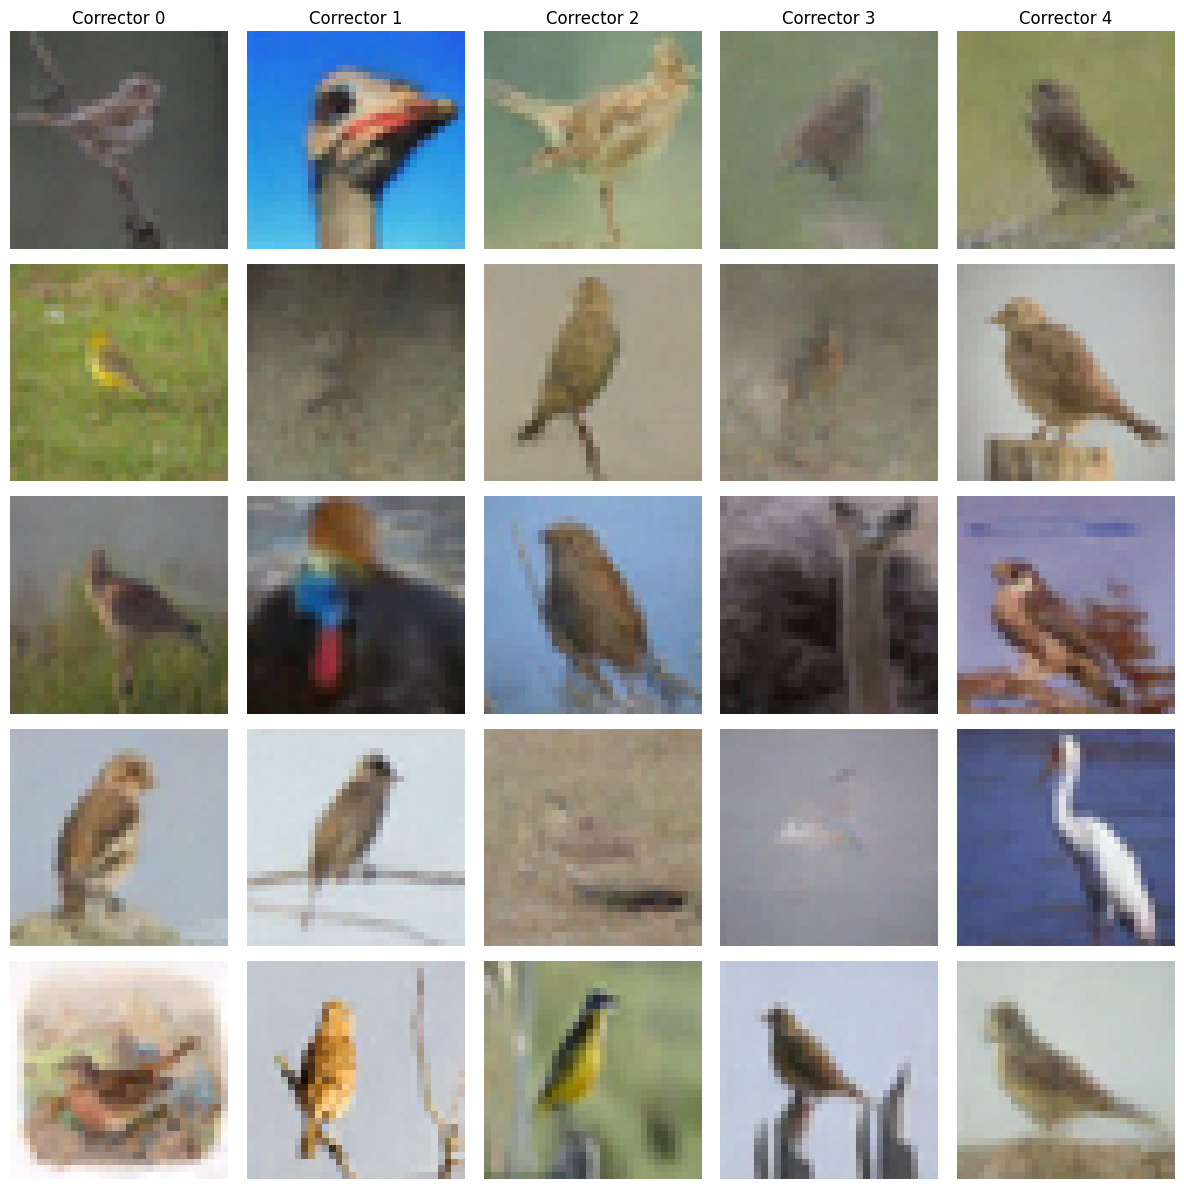

In [5]:
# Visualize generated samples for corrector steps 1, 2, 3, 4
# 5 rows x 4 columns: one column per corrector step


# Corrector steps to visualize
VIS_CORRECTOR_STEPS = [0,1, 2, 3, 4]

# Number of images per corrector step
VIS_NUM_IMAGES_PER_STEP = 5

# Seed for reproducible visualization
VIS_RANDOM_SEED = 123

# Use existing sampling settings if available
VIS_NUM_STEPS = globals().get("SAMPLE_NUM_STEPS", 1000)
VIS_EPS = globals().get("SAMPLE_EPS", 1e-3)
VIS_SNR = globals().get("SAMPLE_SNR", 0.01)

# Checks

required_names = ['load_model_from_checkpoint', 'sample_vp_sde', 'IMAGE_SHAPE', 'BETA_MIN', 'BETA_MAX', 'device']

missing = [name for name in required_names if name not in globals()]

if missing:
    raise RuntimeError('Run the VP U-Net FID/corrector-sweep cell first. Missing definitions: ' + ', '.join(missing))

# Helper

def denormalize_for_plot(x):
    """
    Convert images from [-1, 1] to [0, 1].
    Input shape: [B, C, H, W]
    Output shape: [B, H, W, C]
    """
    x = (x / 2 + 0.5).clamp(0, 1)
    x = x.permute(0, 2, 3, 1)
    return x.cpu().numpy()


@torch.no_grad()
def generate_visual_samples(model, corrector_steps):
    torch.manual_seed(VIS_RANDOM_SEED)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(VIS_RANDOM_SEED)

        samples = sample_vp_sde(net=model, num_samples=VIS_NUM_IMAGES_PER_STEP, img_shape=IMAGE_SHAPE,
            num_steps=VIS_NUM_STEPS, eps=VIS_EPS, snr=VIS_SNR, corrector_steps=corrector_steps, beta_min=BETA_MIN,
            beta_max=BETA_MAX, denoise=True)

    return samples.detach().cpu()


# Generate samples

model=load_model_from_checkpoint()
model.eval()

samples_by_step = {}

for corrector_steps in VIS_CORRECTOR_STEPS:
    print(f"Generating {VIS_NUM_IMAGES_PER_STEP} samples with corrector_steps={corrector_steps}")

    samples = generate_visual_samples(model=model, corrector_steps=corrector_steps)

    samples_by_step[corrector_steps] = denormalize_for_plot(samples)

model.to("cpu")
del model

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# Plot grid

num_rows = VIS_NUM_IMAGES_PER_STEP
num_cols = len(VIS_CORRECTOR_STEPS)

fig, axes = plt.subplots(num_rows, num_cols, figsize=(2.4 * num_cols, 2.4 * num_rows))

for col_idx, corrector_steps in enumerate(VIS_CORRECTOR_STEPS):
    images = samples_by_step[corrector_steps]

    for row_idx in range(num_rows):
        ax = axes[row_idx, col_idx]

        ax.imshow(images[row_idx])
        ax.axis("off")

    if row_idx == 0:
        ax.set_title(f"Corrector {corrector_steps}")

plt.tight_layout()
plt.show()


## Loss History Plot


Mounted at /content/drive

Loading: Bird VE NCSN++ non-augmented
Checkpoint: /content/drive/MyDrive/DD2424/Project/working_nets/bird_ncsnpp_ve_ema_checkpoint_epoch_1760.pth
Found loss history at: checkpoint
Raw points up to 70k: 1758
Plotted points: 1559
Min iteration: 199
Max iteration: 1757
Final plotted loss: 0.08917269478458911

Loading: Bird VE NCSN++ augmented
Checkpoint: /content/drive/MyDrive/DD2424/Project/working_nets/bird_ve_sde_augmented_final_ncsnpp_1760_epochs.pth
Found loss history at: checkpoint
Raw points up to 70k: 70001
Plotted points: 69802
Min iteration: 199
Max iteration: 70000
Final plotted loss: 0.11899205613881352

Loading: Bird VP DDPM++ augmented
Checkpoint: /content/drive/MyDrive/DD2424/Project/working_nets/bird_vp_sde_augmented_final_ddpmpp_1760_epochs.pth
Found loss history at: checkpoint
Raw points up to 70k: 70001
Plotted points: 69802
Min iteration: 199
Max iteration: 70000
Final plotted loss: 0.026669049765914683

Loading: Bird VP DDPM++ non-augmented


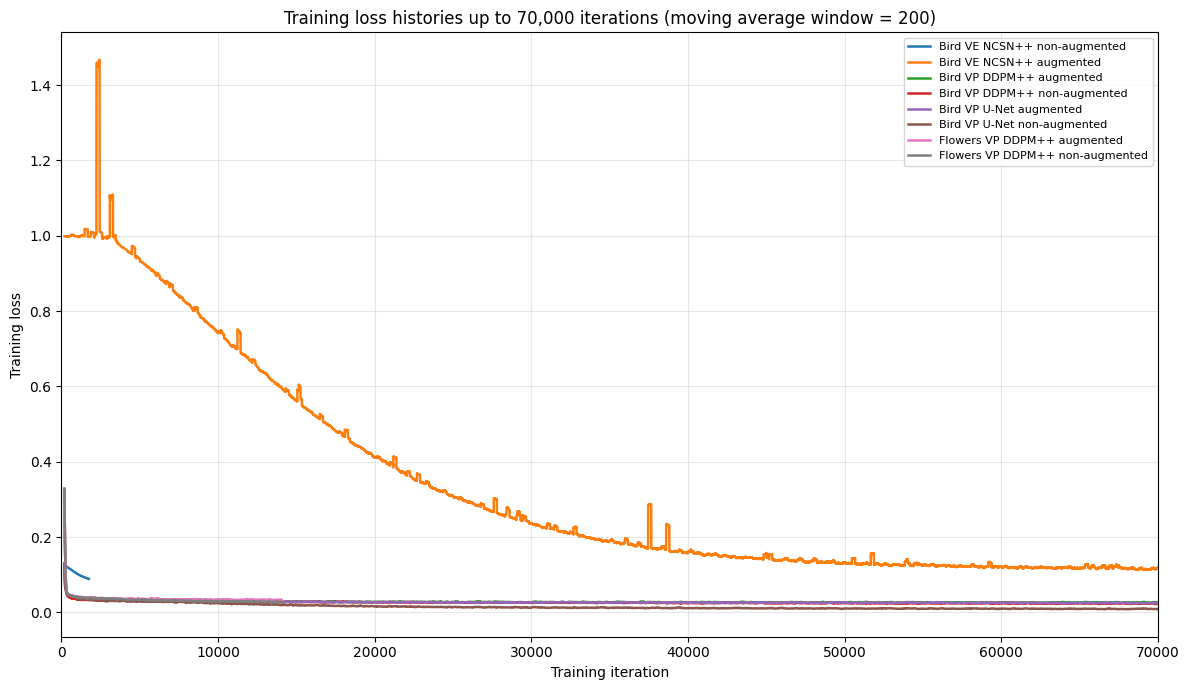

In [3]:
# Plot checkpointed loss histories up to 70k iterations.

try:
    from google.colab import drive
    try:
        drive.mount("/content/drive")
    except ValueError:
        pass
except Exception as e:
    print("Google Drive mount skipped:", repr(e))

PROJECT_PATH = "/content/drive/MyDrive/DD2424/Project/working_nets"
MAX_ITERATION_TO_PLOT = 70_000
LOG_EVERY_N_ITER = 1
SMOOTH_LOSS = True
SMOOTH_WINDOW = 200
SAVE_LOSS_FIGURE = True
LOSS_FIGURE_DIR = os.path.join(PROJECT_PATH, "results", "appendix_figures")
LOSS_FIGURE_PATH = os.path.join(LOSS_FIGURE_DIR, "loss_history_up_to_70k.png")
MODEL_NAMES_TO_PLOT_LOSS = None

MODEL_SPECS_FOR_LOSS = [
    {"name": "bird_ve_ncsnpp_non_augmented_raw_1760", "label": "Bird VE NCSN++ non-augmented", "checkpoint": "bird_ncsnpp_ve_ema_checkpoint_epoch_1760.pth"},
    {"name": "bird_ve_ncsnpp_augmented_raw_1760", "label": "Bird VE NCSN++ augmented", "checkpoint": "bird_ve_sde_augmented_final_ncsnpp_1760_epochs.pth"},
    {"name": "bird_vp_ddpmpp_augmented_raw_1760", "label": "Bird VP DDPM++ augmented", "checkpoint": "bird_vp_sde_augmented_final_ddpmpp_1760_epochs.pth"},
    {"name": "bird_vp_ddpmpp_non_augmented_raw_1760", "label": "Bird VP DDPM++ non-augmented", "checkpoint": "bird_vp_sde_non_augmented_final_ddpmpp_1760_epochs.pth"},
    {"name": "bird_vp_unet_augmented_raw_1760", "label": "Bird VP U-Net augmented", "checkpoint": "bird_vp_sde_augmented_final_U_net_1760_epochs.pth"},
    {"name": "bird_vp_unet_non_augmented_raw_1760", "label": "Bird VP U-Net non-augmented", "checkpoint": "bird_vp_sde_checkpoint_1760_epochs.pth"},
    {"name": "flower_vp_ddpmpp_augmented_raw_1760", "label": "Flowers VP DDPM++ augmented", "checkpoint": "flower_vp_sde_augmented_final_ddpmpp_1760_epochs.pth"},
    {"name": "flower_vp_ddpmpp_non_augmented_raw_1760", "label": "Flowers VP DDPM++ non-augmented", "checkpoint": "flower_vp_sde_non_augmented_final_ddpmpp_1760_epochs.pth"},
]


def torch_load_checkpoint_for_loss(checkpoint_path):
    try:
        return torch.load(checkpoint_path, map_location="cpu", weights_only=False)
    except TypeError:
        return torch.load(checkpoint_path, map_location="cpu")


def looks_like_state_dict(obj):
    if not isinstance(obj, dict) or len(obj) < 10:
        return False

    tensor_values = 0
    checked_values = 0
    for value in obj.values():
        checked_values += 1
        if torch.is_tensor(value):
            tensor_values += 1
        if checked_values >= 30:
            break

    return tensor_values >= max(5, int(0.8 * checked_values))


def is_numeric_sequence(obj):
    if isinstance(obj, torch.Tensor):
        return obj.numel() > 1 and torch.is_floating_point(obj)
    if isinstance(obj, np.ndarray):
        return obj.size > 1 and np.issubdtype(obj.dtype, np.number)
    if isinstance(obj, (list, tuple)) and len(obj) > 1:
        try:
            arr = np.asarray(obj, dtype=np.float64)
            return arr.size > 1 and np.issubdtype(arr.dtype, np.number)
        except Exception:
            return False
    return False


def to_numpy_array(obj):
    if isinstance(obj, torch.Tensor):
        return obj.detach().cpu().float().numpy()
    if isinstance(obj, np.ndarray):
        return obj.astype(np.float64)
    if isinstance(obj, (list, tuple)):
        return np.asarray(obj, dtype=np.float64)
    raise TypeError(f"Cannot convert type {type(obj)} to numpy array.")


def extract_xy_from_loss_object(obj):
    if is_numeric_sequence(obj):
        arr = to_numpy_array(obj)
        if arr.ndim == 2 and arr.shape[1] >= 2:
            return arr[:, 0].reshape(-1), arr[:, 1].reshape(-1)
        if arr.ndim == 1:
            return None, arr.reshape(-1)

    if isinstance(obj, (list, tuple)) and len(obj) > 1 and isinstance(obj[0], dict):
        loss_keys = ["loss", "train_loss", "training_loss", "score_loss", "total_loss", "ema_loss"]
        step_keys = ["iteration", "iterations", "iter", "iters", "step", "steps", "global_step", "global_steps"]
        available_keys = set(obj[0].keys())
        chosen_loss_key = next((key for key in loss_keys if key in available_keys), None)
        if chosen_loss_key is None:
            return None, None

        chosen_step_key = next((key for key in step_keys if key in available_keys), None)
        y_values = [row[chosen_loss_key] for row in obj if chosen_loss_key in row]
        y = np.asarray(y_values, dtype=np.float64)
        if chosen_step_key is not None:
            x_values = [row[chosen_step_key] for row in obj if chosen_step_key in row]
            if len(x_values) == len(y_values):
                return np.asarray(x_values, dtype=np.float64), y
        return None, y

    if isinstance(obj, dict):
        loss_keys = [
            "loss_history", "train_loss_history", "training_loss_history", "loss_hist", "train_loss_hist",
            "losses", "train_losses", "training_losses", "all_losses", "loss_log", "train_loss_log",
            "history_loss", "loss", "train_loss"
        ]
        step_keys = ["iterations", "iteration", "iters", "iter", "steps", "step", "global_steps", "global_step"]
        chosen_loss_key = next((key for key in loss_keys if key in obj and is_numeric_sequence(obj[key])), None)
        if chosen_loss_key is None:
            return None, None

        y_arr = to_numpy_array(obj[chosen_loss_key])
        if y_arr.ndim == 2 and y_arr.shape[1] >= 2:
            return y_arr[:, 0].reshape(-1), y_arr[:, 1].reshape(-1)

        y = y_arr.reshape(-1)
        chosen_step_key = next((key for key in step_keys if key in obj and is_numeric_sequence(obj[key])), None)
        if chosen_step_key is not None:
            x = to_numpy_array(obj[chosen_step_key]).reshape(-1)
            min_len = min(len(x), len(y))
            return x[:min_len], y[:min_len]
        return None, y

    return None, None


def recursively_find_loss_history(obj, max_depth=6, current_depth=0, path="checkpoint"):
    x, y = extract_xy_from_loss_object(obj)
    if y is not None:
        return x, y, path
    if current_depth >= max_depth:
        return None, None, None

    if isinstance(obj, dict):
        if looks_like_state_dict(obj):
            return None, None, None
        keys = list(obj.keys())
        priority_keys = [key for key in keys if any(token in str(key).lower() for token in ["loss", "history", "log"])]
        scan_keys = priority_keys + [key for key in keys if key not in priority_keys]

        for key in scan_keys:
            value = obj[key]
            if torch.is_tensor(value) and value.numel() > 10_000:
                continue
            x, y, found_path = recursively_find_loss_history(value, max_depth=max_depth, current_depth=current_depth + 1, path=f"{path}.{key}")
            if y is not None:
                return x, y, found_path

    if isinstance(obj, (list, tuple)):
        for index, value in enumerate(obj[:20]):
            x, y, found_path = recursively_find_loss_history(value, max_depth=max_depth, current_depth=current_depth + 1, path=f"{path}[{index}]")
            if y is not None:
                return x, y, found_path

    return None, None, None


def make_iteration_axis(num_points):
    return np.arange(num_points, dtype=np.float64) * LOG_EVERY_N_ITER


def clean_loss_curve(x, y, max_iteration):
    y = np.asarray(y, dtype=np.float64).reshape(-1)
    x = make_iteration_axis(len(y)) if x is None else np.asarray(x, dtype=np.float64).reshape(-1)
    min_len = min(len(x), len(y))
    x, y = x[:min_len], y[:min_len]

    finite_mask = np.isfinite(x) & np.isfinite(y)
    x, y = x[finite_mask], y[finite_mask]
    keep_mask = x <= max_iteration
    return x[keep_mask], y[keep_mask]


def moving_average(y, window):
    y = np.asarray(y, dtype=np.float64)
    if window <= 1 or len(y) < window:
        return y
    kernel = np.ones(window, dtype=np.float64) / window
    return np.convolve(y, kernel, mode="valid")


def smooth_curve_preserving_x(x, y, window):
    if not SMOOTH_LOSS or window <= 1 or len(y) < window:
        return x, y
    y_smooth = moving_average(y, window)
    return x[window - 1:], y_smooth


selected_names = None if MODEL_NAMES_TO_PLOT_LOSS is None else set(MODEL_NAMES_TO_PLOT_LOSS)
loss_curves = []

for spec in MODEL_SPECS_FOR_LOSS:
    if selected_names is not None and spec["name"] not in selected_names:
        continue

    checkpoint_path = os.path.join(PROJECT_PATH, spec["checkpoint"])
    if not os.path.exists(checkpoint_path):
        print("\nSkipping missing checkpoint:")
        print(checkpoint_path)
        continue

    print("\n====================================")
    print("Loading:", spec["label"])
    print("Checkpoint:", checkpoint_path)
    print("====================================")

    checkpoint = torch_load_checkpoint_for_loss(checkpoint_path)
    x, y, found_path = recursively_find_loss_history(checkpoint)

    if y is None:
        print("No loss history found in this checkpoint.")
        if isinstance(checkpoint, dict):
            print("Top-level checkpoint keys:")
            print(list(checkpoint.keys()))
        del checkpoint
        gc.collect()
        continue

    x, y = clean_loss_curve(x, y, MAX_ITERATION_TO_PLOT)
    if len(y) == 0:
        print("Loss history exists, but no points are <= 70k iterations.")
        del checkpoint
        gc.collect()
        continue

    x_plot, y_plot = smooth_curve_preserving_x(x, y, SMOOTH_WINDOW)
    print("Found loss history at:", found_path)
    print("Raw points up to 70k:", len(y))
    print("Plotted points:", len(y_plot))
    print("Min iteration:", int(x_plot.min()))
    print("Max iteration:", int(x_plot.max()))
    print("Final plotted loss:", float(y_plot[-1]))
    loss_curves.append({"name": spec["name"], "label": spec["label"], "x": x_plot, "y": y_plot, "found_path": found_path})

    del checkpoint
    gc.collect()

if len(loss_curves) == 0:
    raise RuntimeError("No loss histories were found. Check the printed checkpoint keys and loss key candidates.")

plt.figure(figsize=(12, 7))
for curve in loss_curves:
    plt.plot(curve["x"], curve["y"], linewidth=1.8, label=curve["label"])

plt.xlabel("Training iteration")
plt.ylabel("Training loss")
if SMOOTH_LOSS:
    plt.title(f"Training loss histories up to {MAX_ITERATION_TO_PLOT:,} iterations (moving average window = {SMOOTH_WINDOW})")
else:
    plt.title(f"Training loss histories up to {MAX_ITERATION_TO_PLOT:,} iterations")

plt.xlim(0, MAX_ITERATION_TO_PLOT)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=8)
plt.tight_layout()

if SAVE_LOSS_FIGURE:
    os.makedirs(LOSS_FIGURE_DIR, exist_ok=True)
    plt.savefig(LOSS_FIGURE_PATH, dpi=300, bbox_inches="tight")
    print("\nSaved loss-history figure to:")
    print(LOSS_FIGURE_PATH)

plt.show()
